In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("INNHotelsGroup.csv")
sns.set(style="whitegrid")

# Check initial distribution of booking status
print("Initial Booking Status Distribution:")
print(df['booking_status'].value_counts())

Initial Booking Status Distribution:
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


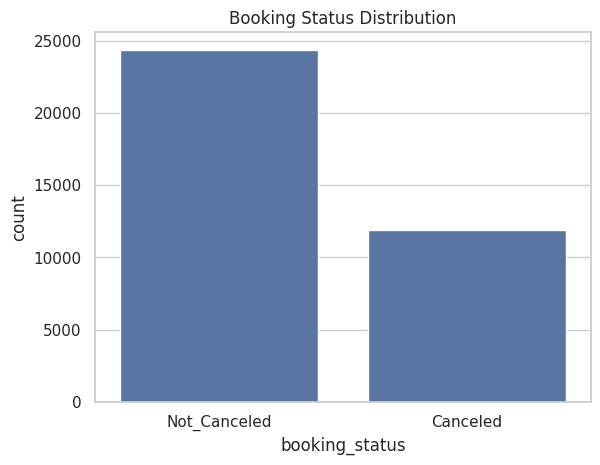

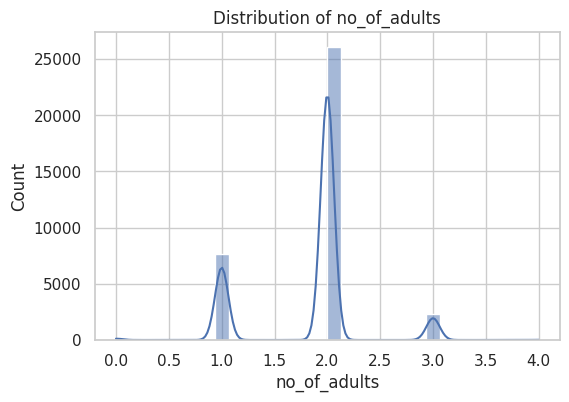

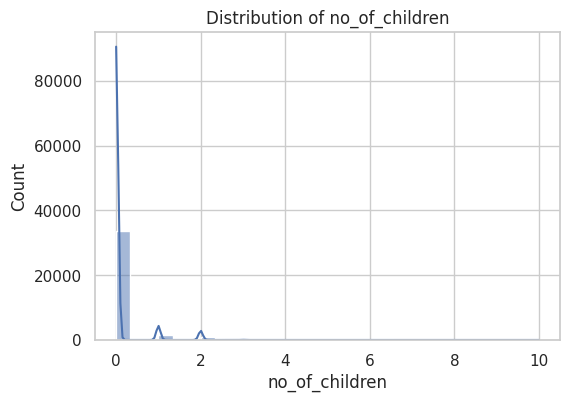

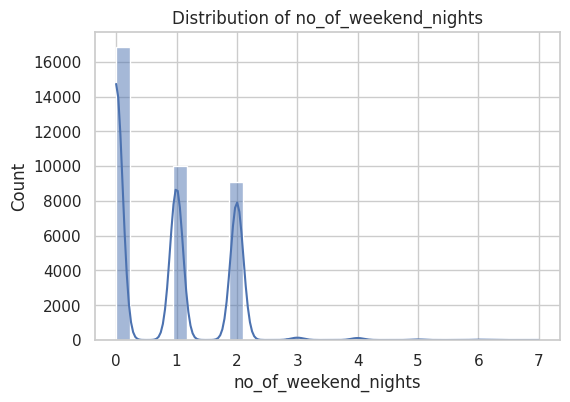

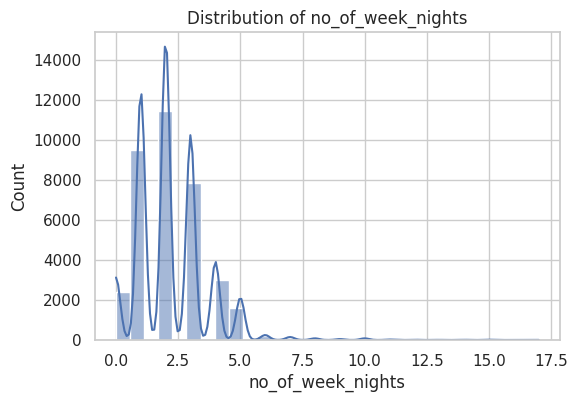

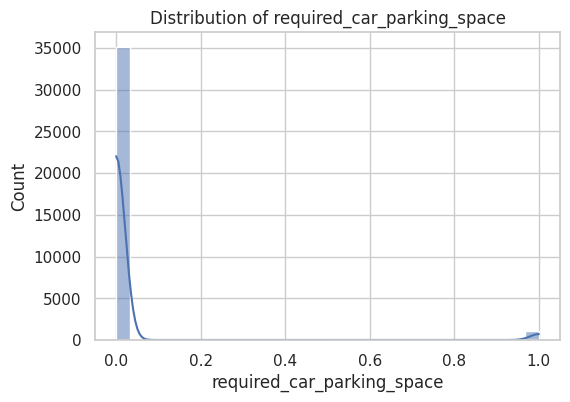

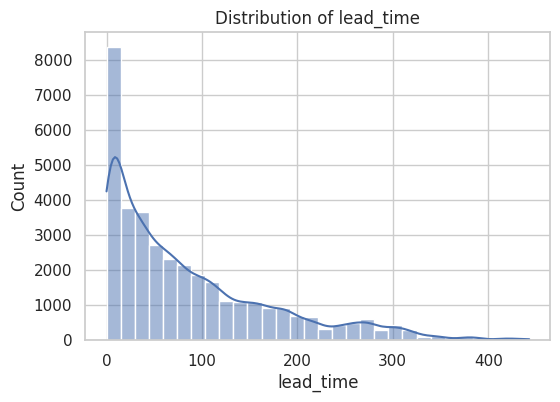

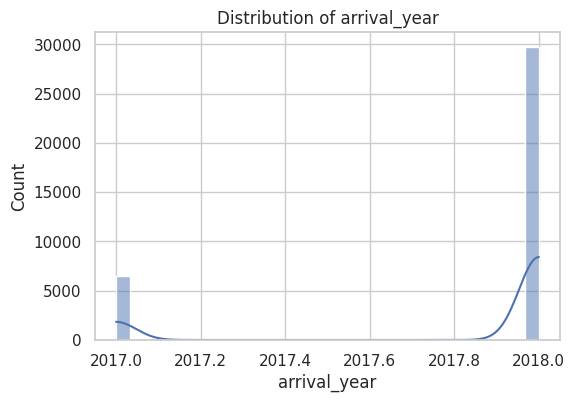

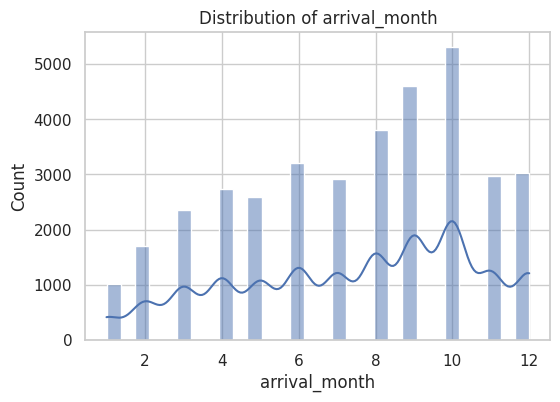

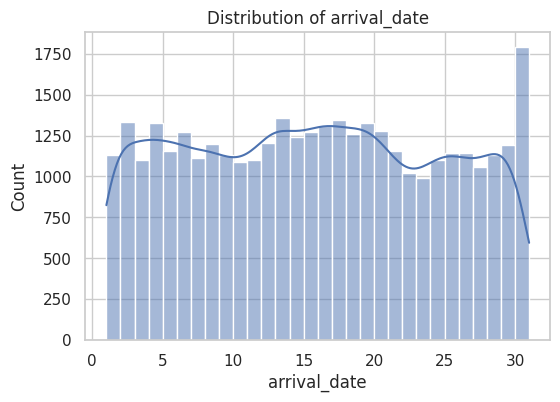

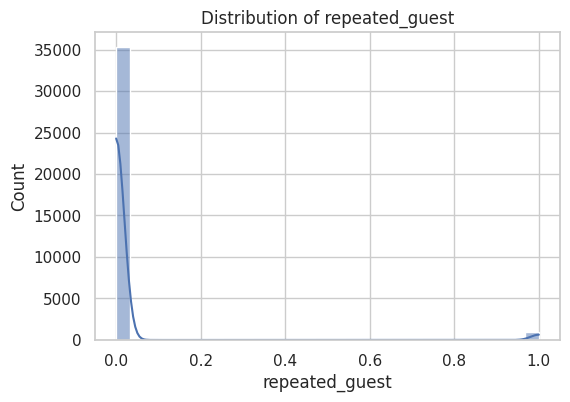

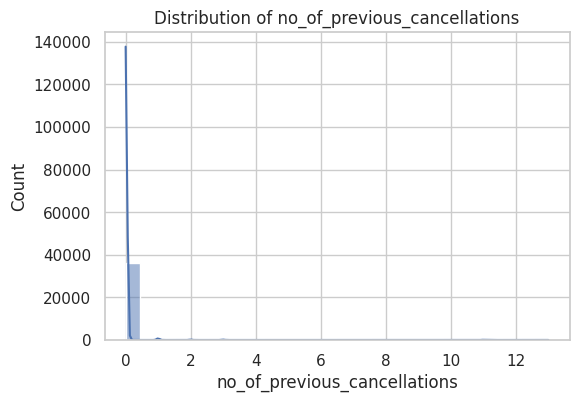

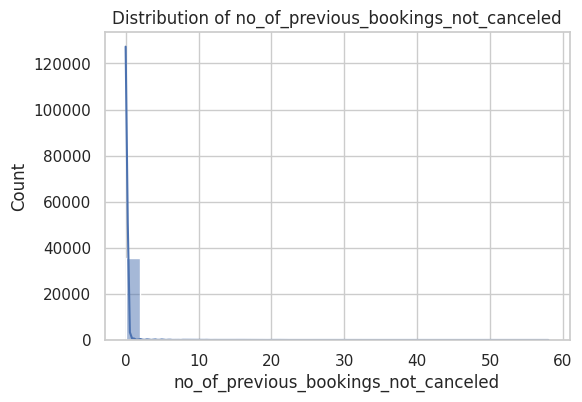

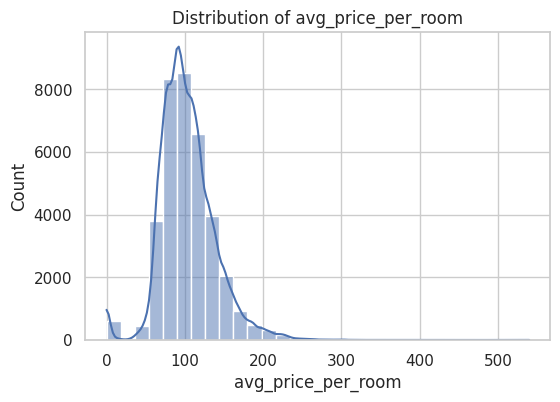

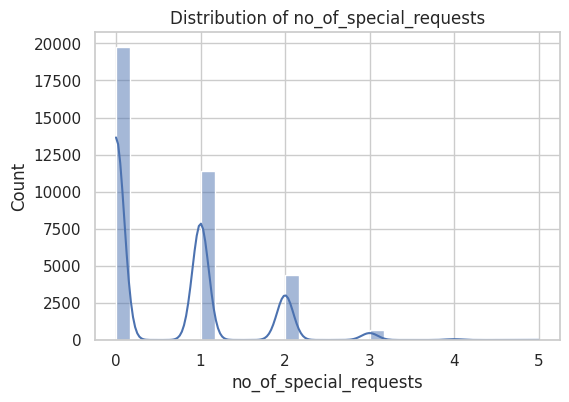

In [ ]:
# Target variable distribution
sns.countplot(x="booking_status", data=df)
plt.title("Booking Status Distribution")
plt.show()

# Univariate for numeric features
num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

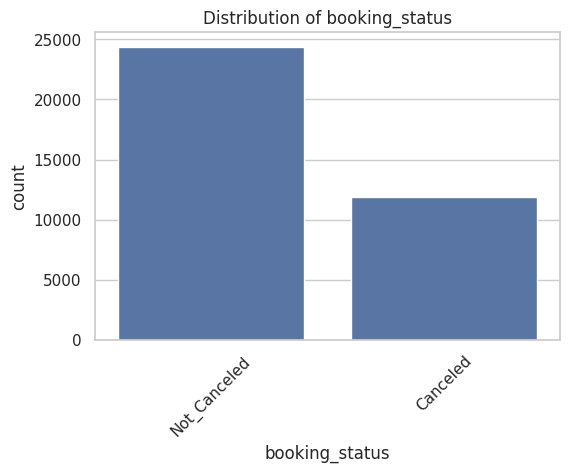

In [ ]:
# Univariate for categorical features
cat_cols = df.select_dtypes(include=["object"]).columns.drop("Booking_ID")

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()


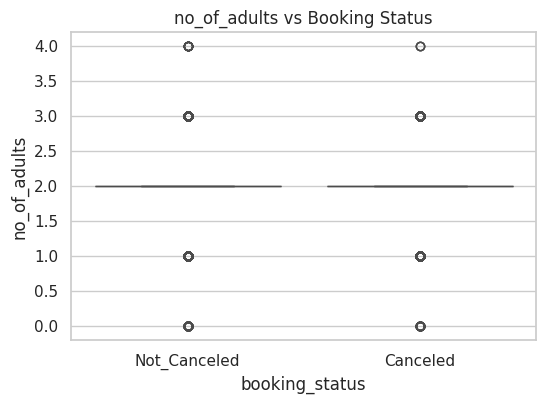

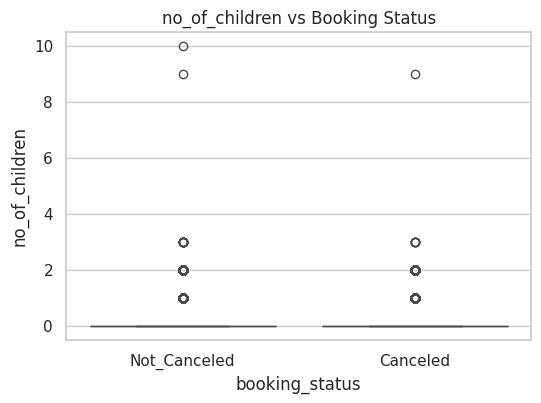

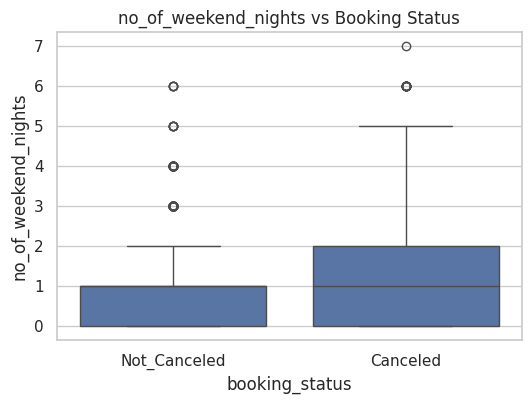

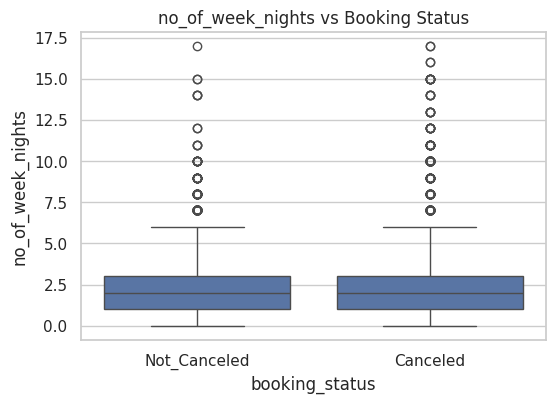

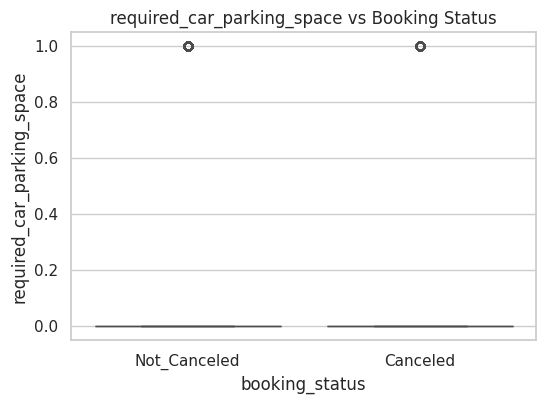

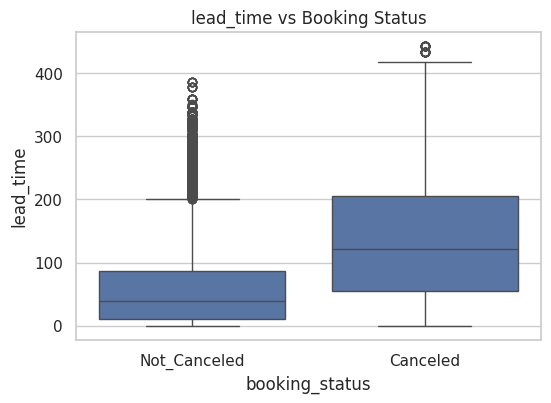

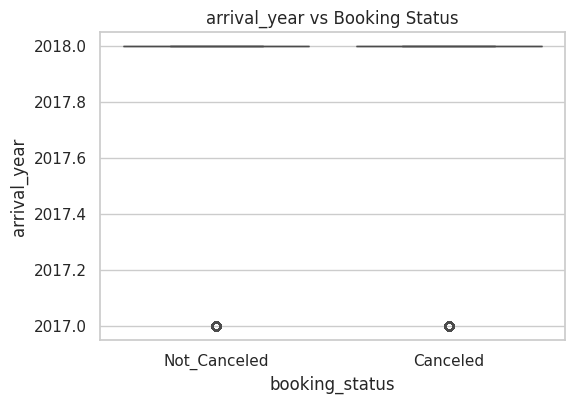

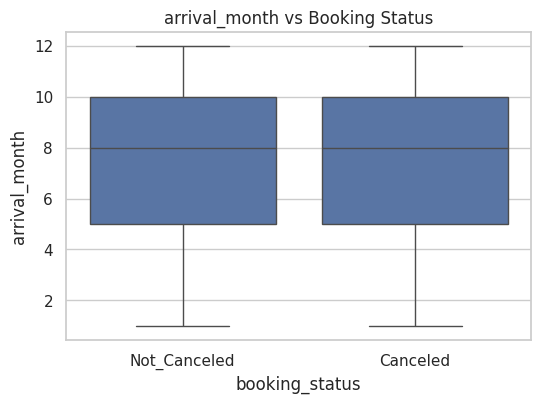

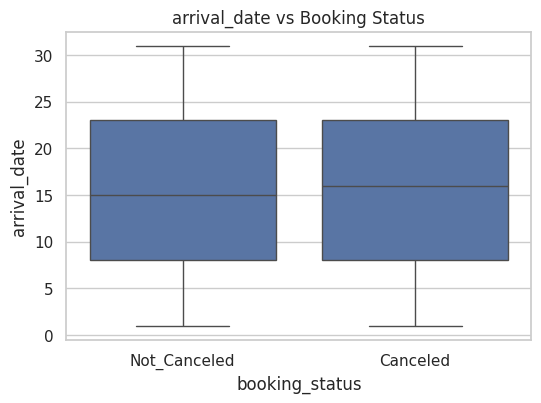

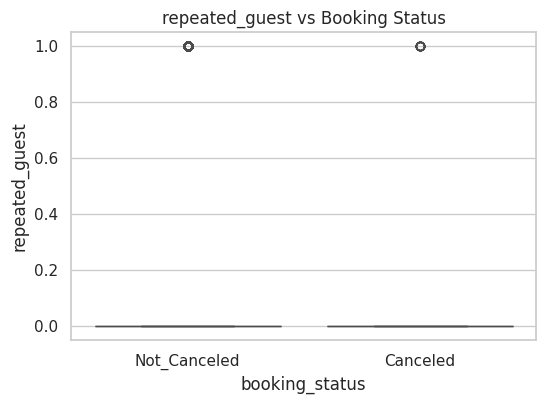

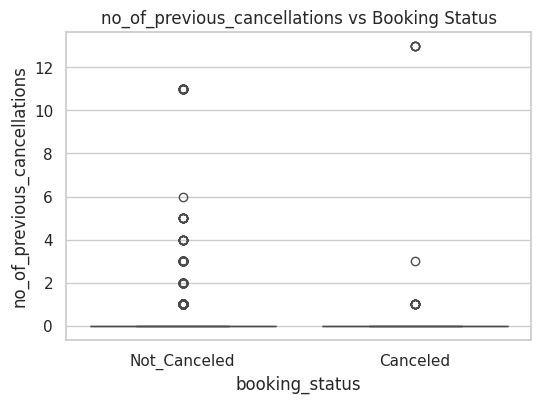

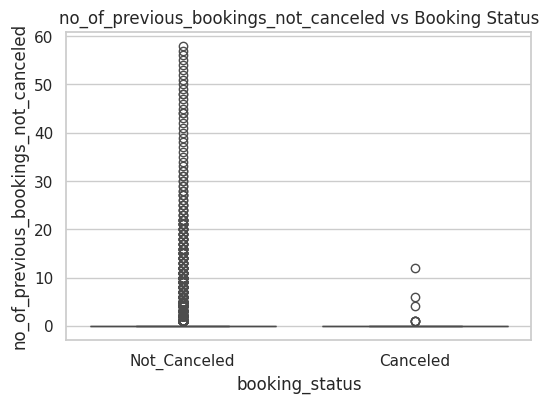

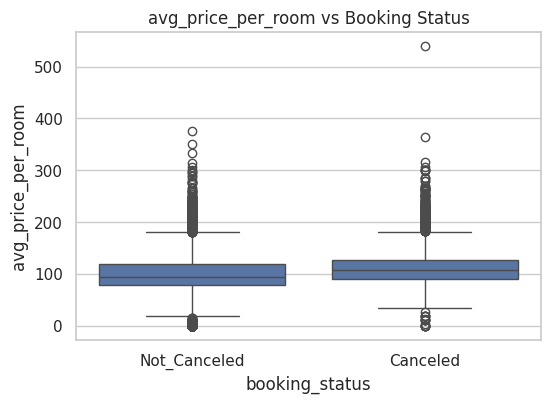

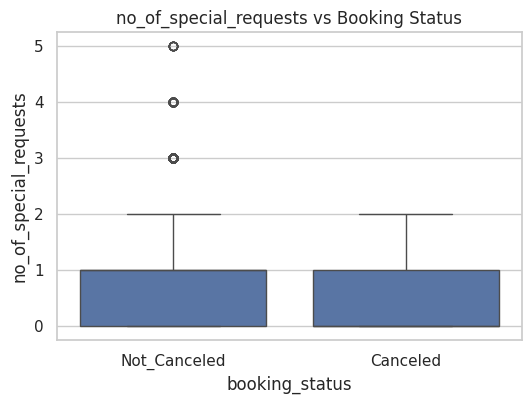

In [ ]:
# Numerical features vs Target
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="booking_status", y=col, data=df)
    plt.title(f"{col} vs Booking Status")
    plt.show()

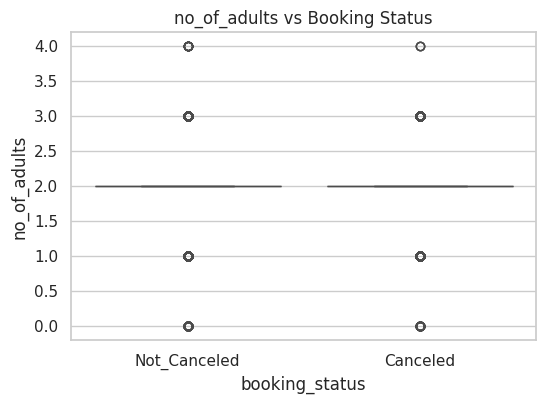

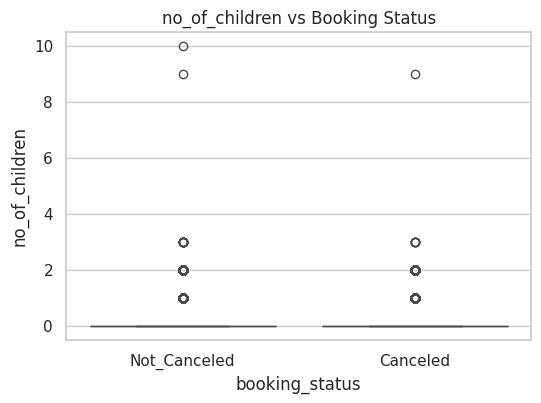

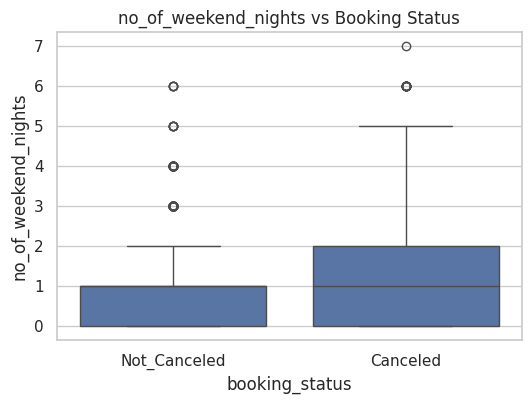

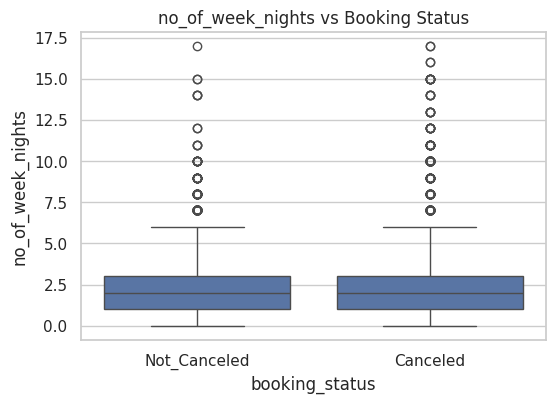

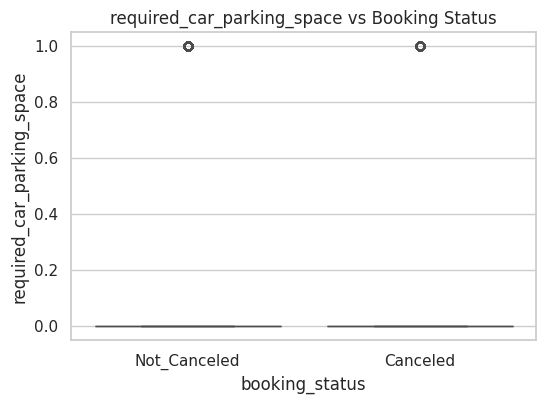

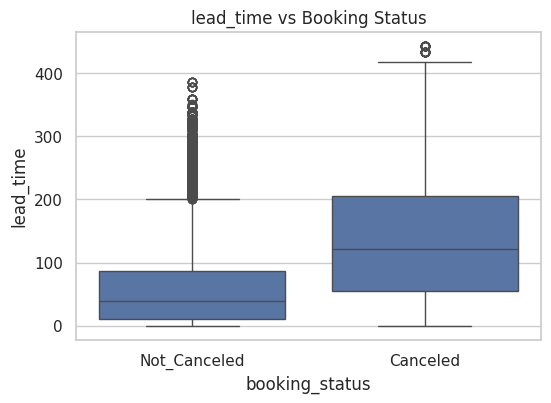

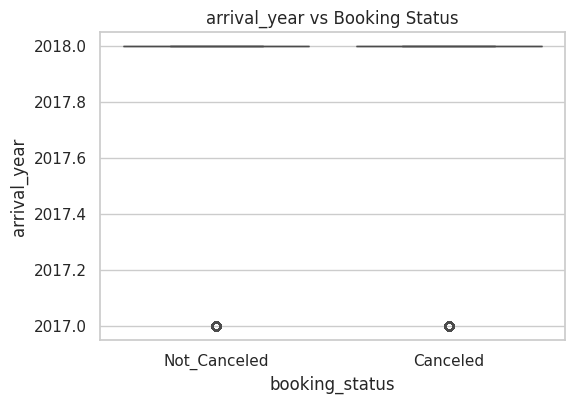

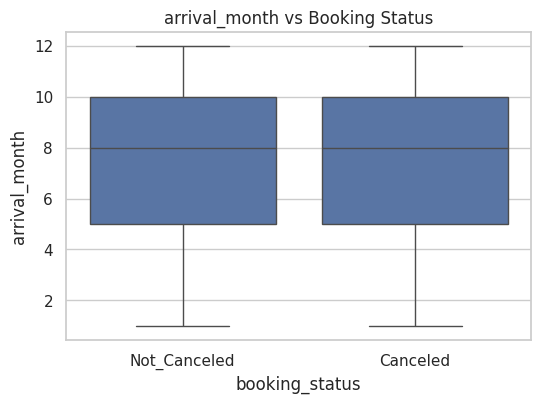

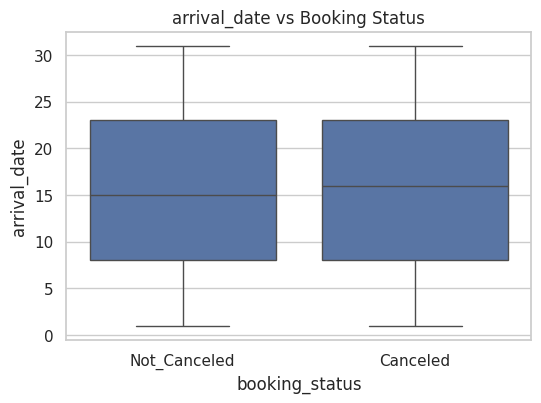

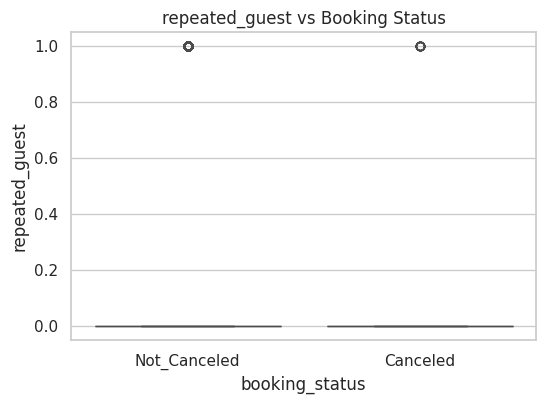

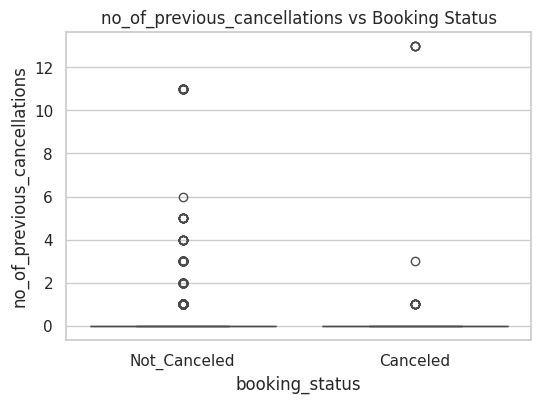

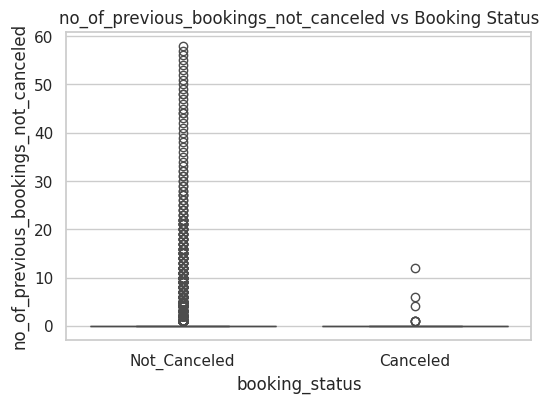

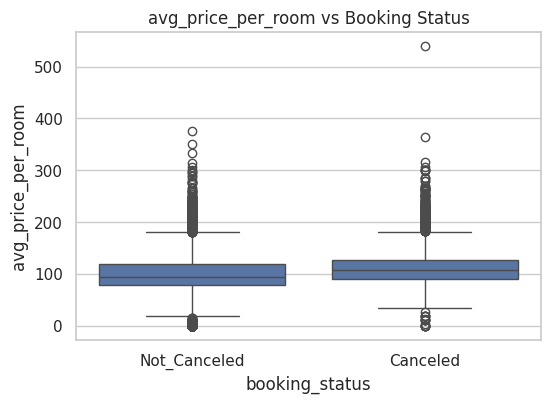

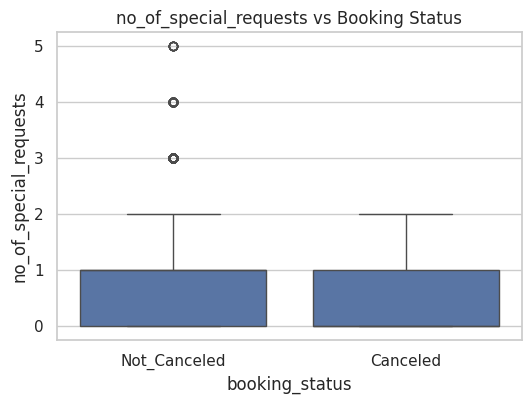

In [ ]:
# Numerical features vs Target
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="booking_status", y=col, data=df)
    plt.title(f"{col} vs Booking Status")
    plt.show()

In [ ]:
busiest_months = df['arrival_month'].value_counts(normalize=True) * 100
print(busiest_months)

arrival_month
10    14.657478
9     12.711234
8     10.511371
6      8.829773
12     8.328050
11     8.215024
7      8.049621
4      7.542385
5      7.161957
3      6.500345
2      4.697450
1      2.795314
Name: proportion, dtype: float64


In [ ]:
market_segment = df['market_segment_type'].value_counts(normalize=True) * 100
print(market_segment)

market_segment_type
Online           63.994487
Offline          29.022743
Corporate         5.560303
Complementary     1.077877
Aviation          0.344590
Name: proportion, dtype: float64


In [ ]:
avg_price_segment = df.groupby('market_segment_type')['avg_price_per_room'].mean().sort_values(ascending=False)
print(avg_price_segment)

market_segment_type
Online           112.256855
Aviation         100.704000
Offline           91.632679
Corporate         82.911740
Complementary      3.141765
Name: avg_price_per_room, dtype: float64


In [ ]:
cancel_percent = df['booking_status'].value_counts(normalize=True) * 100
print(cancel_percent)

booking_status
Not_Canceled    67.236389
Canceled        32.763611
Name: proportion, dtype: float64


In [ ]:
repeat_cancel = df[df['repeated_guest'] == 1]['booking_status'].value_counts(normalize=True) * 100
print(repeat_cancel)

booking_status
Not_Canceled    98.27957
Canceled         1.72043
Name: proportion, dtype: float64


In [ ]:
special_req_cancel = df.groupby('no_of_special_requests')['booking_status'].value_counts(normalize=True).unstack().fillna(0)
print(special_req_cancel)

booking_status          Canceled  Not_Canceled
no_of_special_requests                        
0                       0.432068      0.567932
1                       0.237668      0.762332
2                       0.145967      0.854033
3                       0.000000      1.000000
4                       0.000000      1.000000
5                       0.000000      1.000000


In [ ]:
df.isnull().values.any()

np.False_

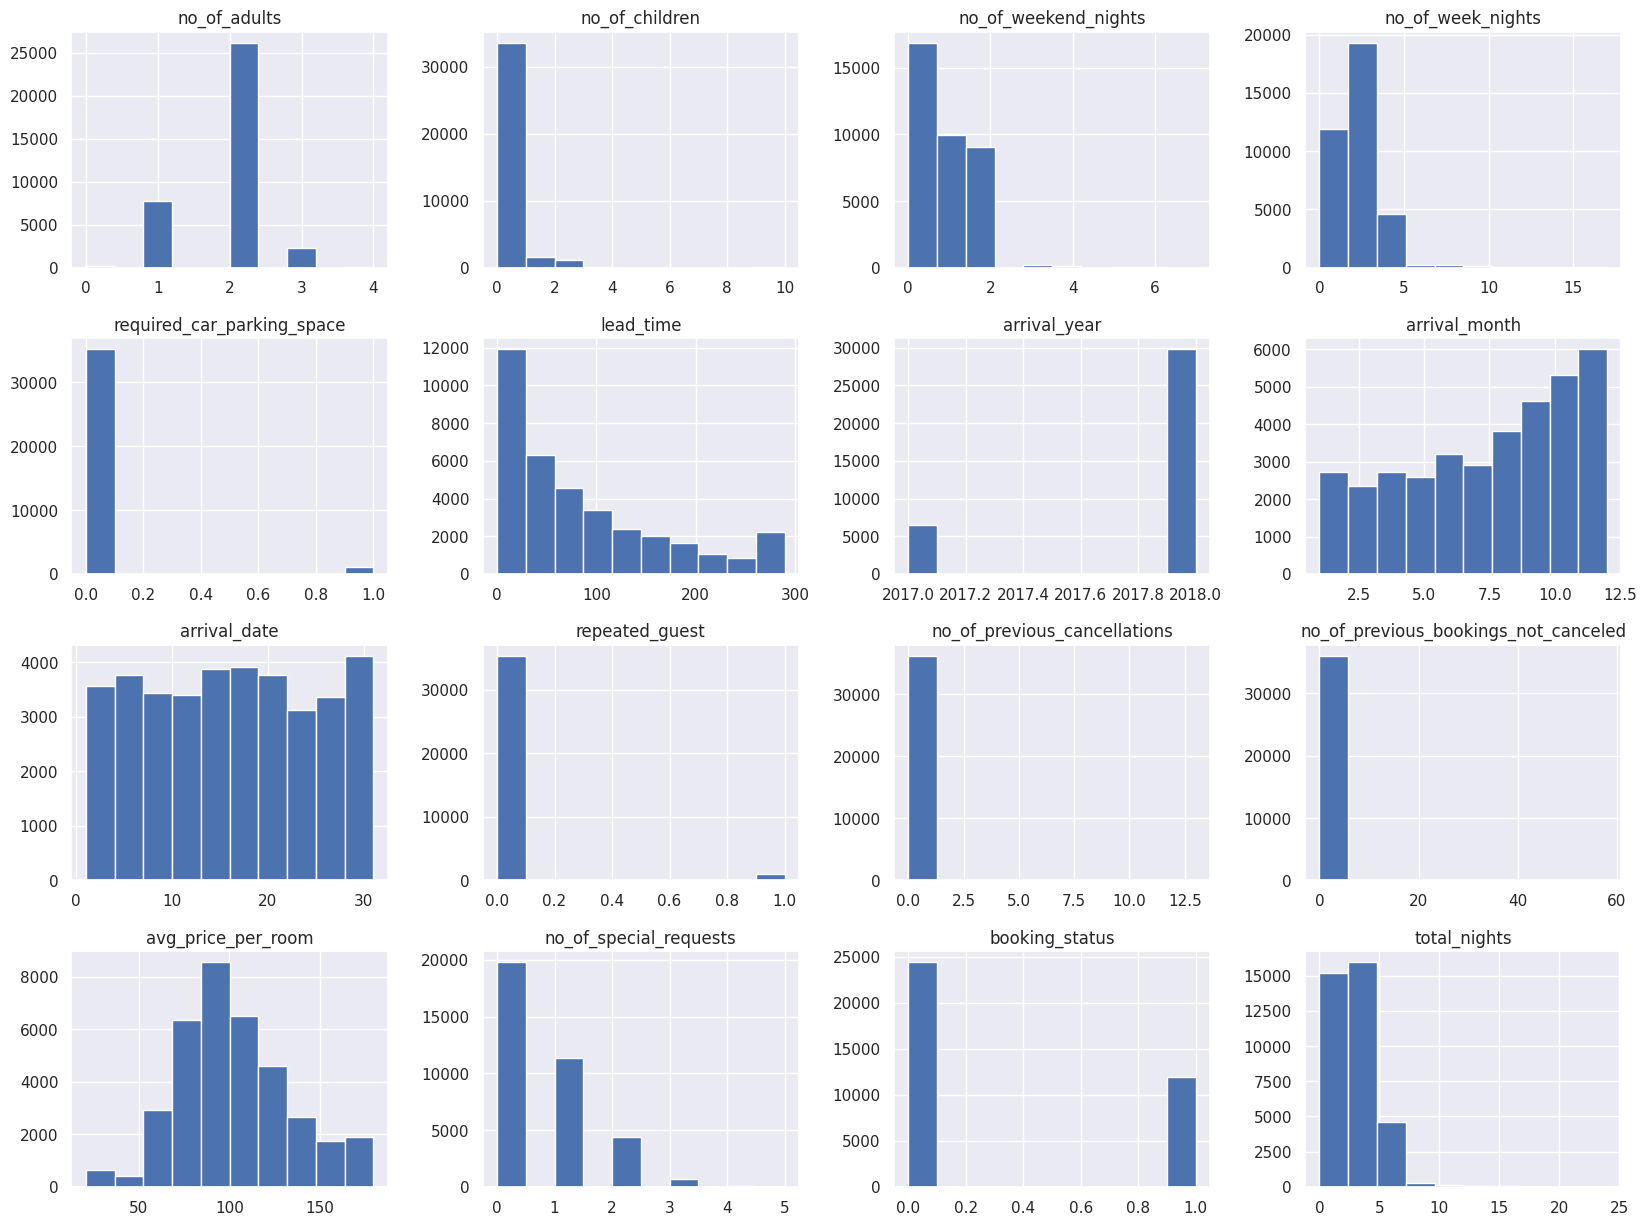

In [ ]:
sns.set_style("darkgrid")
df.hist(figsize=(20, 15))
plt.show()

In [ ]:
print(df.isnull().sum())

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


In [ ]:
import numpy as np

def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] > upper_bound, upper_bound,
                  np.where(df[column] < lower_bound, lower_bound, df[column]))
    return df

# Apply on continuous variables
for col in ["lead_time", "avg_price_per_room"]:
    df = cap_outliers(df, col)

In [ ]:
df["total_nights"] = df["no_of_weekend_nights"] + df["no_of_week_nights"]

# One-Hot Encoding for categorical features
cols_to_encode = ["type_of_meal_plan", "room_type_reserved", "market_segment_type"]
existing_cols_to_encode = [col for col in cols_to_encode if col in df.columns]

if existing_cols_to_encode:
    df = pd.get_dummies(df, columns=existing_cols_to_encode, drop_first=True)
else:
    print("Categorical columns for one-hot encoding not found in DataFrame.")

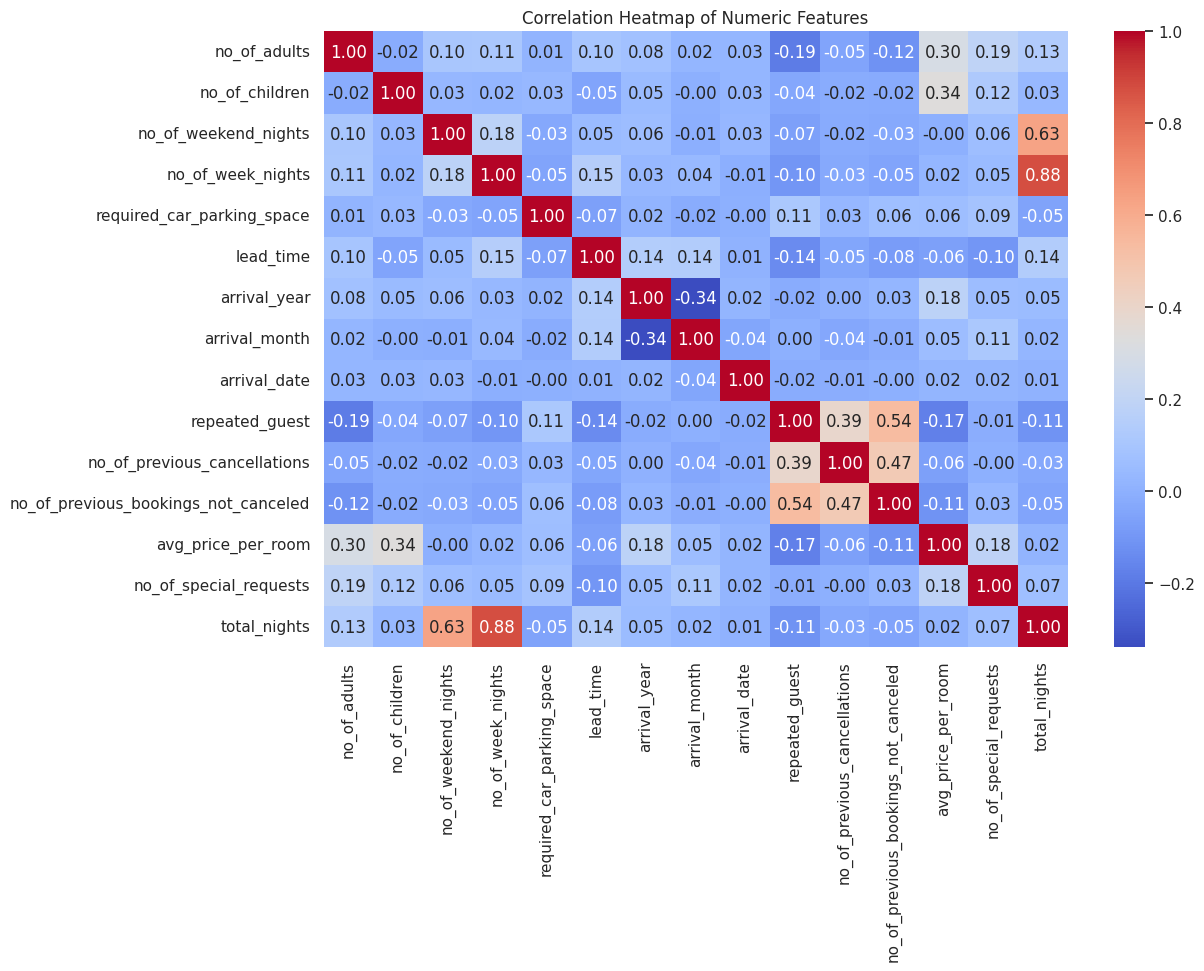

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric features
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define features (X) and target (y)
X = df.drop(columns=['Booking_ID', 'total_nights','booking_status'], axis=1)  # Drop Booking_ID and target variable

# Define target variable
y = df['booking_status']

# Convert target variable to numerical (0 for Not_Canceled, 1 for Canceled)
y = y.apply(lambda x: 1 if x == 'Canceled' else 0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Add a constant to the features for statsmodels
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [ ]:
logit = sm.Logit(y_train, X_train.astype(float))
lg = logit.fit()

         Current function value: 0.426435
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                29020
Model:                          Logit   Df Residuals:                    28992
Method:                           MLE   Df Model:                           27
Date:                Mon, 25 Aug 2025   Pseudo R-squ.:                  0.3258
Time:                        21:06:41   Log-Likelihood:                -12375.
converged:                      False   LL-Null:                       -18355.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -959.5101    113.471     -8.456      0.000   -1181.910    -737.111
no_of_adults                             0.0761      

In [ ]:
pred_train = lg.predict(X_train.astype(float)) > 0.5
pred_train = np.round(pred_train)

In [ ]:
cm = confusion_matrix(y_train, pred_train)
plt.figure(figsize=(4,5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

NameError: name 'y_train' is not defined

In [ ]:
print("Accuracy on training set : ", accuracy_score(y_train, pred_train))

Accuracy on training set :  0.8028600964851826


In [ ]:
vif_series = pd.Series(
    [variance_inflation_factor(X_train.astype(float).values, i) for i in range(X_train.shape[1])],
    index=X_train.columns,
    dtype=float,
)
print("VIF values: \n\n{}\n".format(vif_series))

VIF values: 

const                                   3.959778e+07
no_of_adults                            1.346838e+00
no_of_children                          2.030995e+00
no_of_weekend_nights                    1.068865e+00
no_of_week_nights                       1.097361e+00
required_car_parking_space              1.038448e+00
lead_time                               1.391812e+00
arrival_year                            1.428397e+00
arrival_month                           1.274191e+00
arrival_date                            1.006758e+00
repeated_guest                          1.783440e+00
no_of_previous_cancellations            1.374259e+00
no_of_previous_bookings_not_canceled    1.662942e+00
avg_price_per_room                      2.039241e+00
no_of_special_requests                  1.248432e+00
type_of_meal_plan_Meal Plan 2           1.266243e+00
type_of_meal_plan_Meal Plan 3           1.021240e+00
type_of_meal_plan_Not Selected          1.273427e+00
room_type_reserved_Room_Type 2  

In [ ]:
X_train1 = X_train.drop(["market_segment_type_Complementary", "market_segment_type_Online"], axis=1)

In [ ]:
vif_series1 = pd.Series(
    [variance_inflation_factor(X_train1.astype(float).values, i) for i in range(X_train1.shape[1])],
    index=X_train1.columns,
    dtype=float,
)
print("VIF values (after dropping Complementary and Online market segments): \n\n{}\n".format(vif_series1))

VIF values (after dropping Complementary and Online market segments): 

const                                   3.937312e+07
no_of_adults                            1.330239e+00
no_of_children                          2.030094e+00
no_of_weekend_nights                    1.061316e+00
no_of_week_nights                       1.091533e+00
required_car_parking_space              1.037885e+00
lead_time                               1.372789e+00
arrival_year                            1.420569e+00
arrival_month                           1.267884e+00
arrival_date                            1.006747e+00
repeated_guest                          1.747507e+00
no_of_previous_cancellations            1.370047e+00
no_of_previous_bookings_not_canceled    1.657158e+00
avg_price_per_room                      1.713711e+00
no_of_special_requests                  1.243431e+00
type_of_meal_plan_Meal Plan 2           1.252867e+00
type_of_meal_plan_Meal Plan 3           1.016209e+00
type_of_meal_plan_Not Selec

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
model_sklearn = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model_sklearn.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns for scaling
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the scaler on the training data
X_train_scaled = X_train.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_scaled[numerical_cols])

# Transform the test data using the fitted scaler
X_test_scaled = X_test.copy()
X_test_scaled[numerical_cols] = scaler.transform(X_test_scaled[numerical_cols])

# Initialize and train the Logistic Regression model on scaled data
model_sklearn_scaled = LogisticRegression(max_iter=1000)
model_sklearn_scaled.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Make predictions on the scaled test set
pred_test_scaled = model_sklearn_scaled.predict(X_test_scaled)

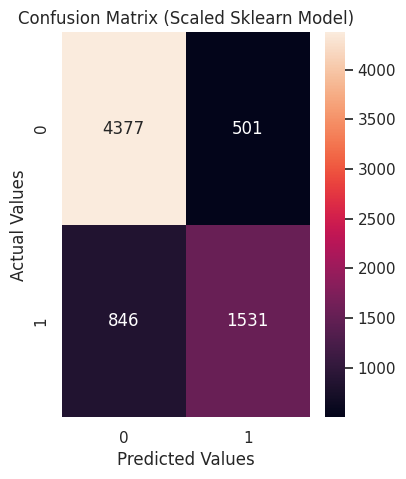

Accuracy on scaled test set: 0.8143
Precision on scaled test set: 0.7534
Recall on scaled test set: 0.6441
F1-score on scaled test set: 0.6945


In [ ]:
# Evaluate model performance on scaled data
cm_scaled = confusion_matrix(y_test, pred_test_scaled)
plt.figure(figsize=(4,5))
sns.heatmap(cm_scaled, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix (Scaled Sklearn Model)")
plt.show()

accuracy_scaled = accuracy_score(y_test, pred_test_scaled)
precision_scaled = precision_score(y_test, pred_test_scaled)
recall_scaled = recall_score(y_test, pred_test_scaled)
f1_scaled = f1_score(y_test, pred_test_scaled)

print(f"Accuracy on scaled test set: {accuracy_scaled:.4f}")
print(f"Precision on scaled test set: {precision_scaled:.4f}")
print(f"Recall on scaled test set: {recall_scaled:.4f}")
print(f"F1-score on scaled test set: {f1_scaled:.4f}")

In [ ]:
logit = sm.Logit(y_train, X_train.astype(float))
lg = logit.fit()
print(lg.summary())

         Current function value: 0.426435
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                29020
Model:                          Logit   Df Residuals:                    28992
Method:                           MLE   Df Model:                           27
Date:                Mon, 25 Aug 2025   Pseudo R-squ.:                  0.3258
Time:                        21:27:05   Log-Likelihood:                -12375.
converged:                      False   LL-Null:                       -18355.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -959.5101    113.471     -8.456      0.000   -1181.910    -737.111
no_of_adults                             0.0761      

In [ ]:
vif_series = pd.Series(
    [variance_inflation_factor(X_train.astype(float).values, i) for i in range(X_train.shape[1])],
    index=X_train.columns,
    dtype=float,
)
print("VIF values: \n\n{}\n".format(vif_series))

VIF values: 

const                                   3.959778e+07
no_of_adults                            1.346838e+00
no_of_children                          2.030995e+00
no_of_weekend_nights                    1.068865e+00
no_of_week_nights                       1.097361e+00
required_car_parking_space              1.038448e+00
lead_time                               1.391812e+00
arrival_year                            1.428397e+00
arrival_month                           1.274191e+00
arrival_date                            1.006758e+00
repeated_guest                          1.783440e+00
no_of_previous_cancellations            1.374259e+00
no_of_previous_bookings_not_canceled    1.662942e+00
avg_price_per_room                      2.039241e+00
no_of_special_requests                  1.248432e+00
type_of_meal_plan_Meal Plan 2           1.266243e+00
type_of_meal_plan_Meal Plan 3           1.021240e+00
type_of_meal_plan_Not Selected          1.273427e+00
room_type_reserved_Room_Type 2  

In [ ]:
logit_refined = sm.Logit(y_train, X_train.astype(float))
lg_refined = logit_refined.fit()
print(lg_refined.summary())

Optimization terminated successfully.
         Current function value: 0.428282
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                29020
Model:                          Logit   Df Residuals:                    29000
Method:                           MLE   Df Model:                           19
Date:                Mon, 25 Aug 2025   Pseudo R-squ.:                  0.3229
Time:                        21:58:12   Log-Likelihood:                -12429.
converged:                       True   LL-Null:                       -18355.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           -964.8366    112.964     -8.541    

In [ ]:
X_train = X_train.drop("no_of_weekend_nights", axis=1)
X_test = X_test.drop("no_of_weekend_nights", axis=1)

In [ ]:
logit_refined = sm.Logit(y_train, X_train.astype(float))
lg_refined = logit_refined.fit()
print(lg_refined.summary())

Optimization terminated successfully.
         Current function value: 0.428282
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                29020
Model:                          Logit   Df Residuals:                    29000
Method:                           MLE   Df Model:                           19
Date:                Mon, 25 Aug 2025   Pseudo R-squ.:                  0.3229
Time:                        21:59:28   Log-Likelihood:                -12429.
converged:                       True   LL-Null:                       -18355.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           -964.8366    112.964     -8.541    

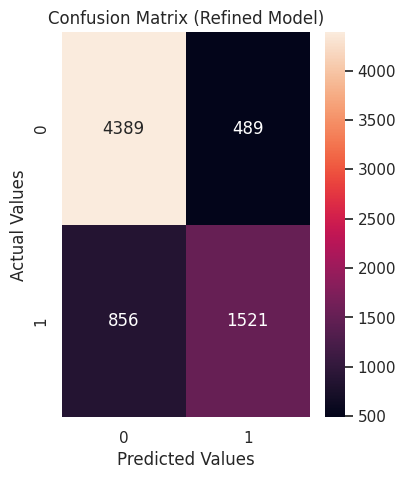

Accuracy on test set (refined model): 0.8146
Precision on test set (refined model): 0.7567
Recall on test set (refined model): 0.6399
F1-score on test set (refined model): 0.6934


In [ ]:
pred_train_refined = lg_refined.predict(X_train.astype(float)) > 0.5
pred_train_refined = np.round(pred_train_refined)

pred_test_refined = lg_refined.predict(X_test.astype(float)) > 0.5
pred_test_refined = np.round(pred_test_refined)

cm_refined = confusion_matrix(y_test, pred_test_refined)
plt.figure(figsize=(4,5))
sns.heatmap(cm_refined, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix (Refined Model)")
plt.show()

accuracy_refined = accuracy_score(y_test, pred_test_refined)
precision_refined = precision_score(y_test, pred_test_refined)
recall_refined = recall_score(y_test, pred_test_refined)
f1_refined = f1_score(y_test, pred_test_refined)

print(f"Accuracy on test set (refined model): {accuracy_refined:.4f}")
print(f"Precision on test set (refined model): {precision_refined:.4f}")
print(f"Recall on test set (refined model): {recall_refined:.4f}")
print(f"F1-score on test set (refined model): {f1_refined:.4f}")

In [ ]:
odds = np.exp(lg_refined.params)

# adding the odds to a dataframe
pd.DataFrame(odds, X_train.columns, columns=["odds"]).T

,const,no_of_adults,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,repeated_guest,no_of_previous_cancellations,...,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Corporate,market_segment_type_Offline
odds,0.0,1.068782,1.164807,1.046103,0.21324,1.015589,1.600638,0.957283,0.060519,1.231845,...,0.233995,1.178923,1.26965,0.764752,0.782091,0.439554,0.510813,0.249349,0.436861,0.176325


In [ ]:
perc_change_odds = (np.exp(lg_refined.params) - 1) * 100

# adding the change_odds% to a dataframe
pd.DataFrame(perc_change_odds, X_train.columns, columns=["change_odds%"]).T

,const,no_of_adults,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,repeated_guest,no_of_previous_cancellations,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Corporate,market_segment_type_Offline
change_odds%,-100.0,8.332866,6.365187,-78.841878,1.555462,61.09337,-4.276062,-94.027019,22.830804,1.831642,-76.386625,18.824202,24.339156,-22.824971,-20.888235,-54.422615,-46.850395,-73.562493,-59.244794,-82.878808


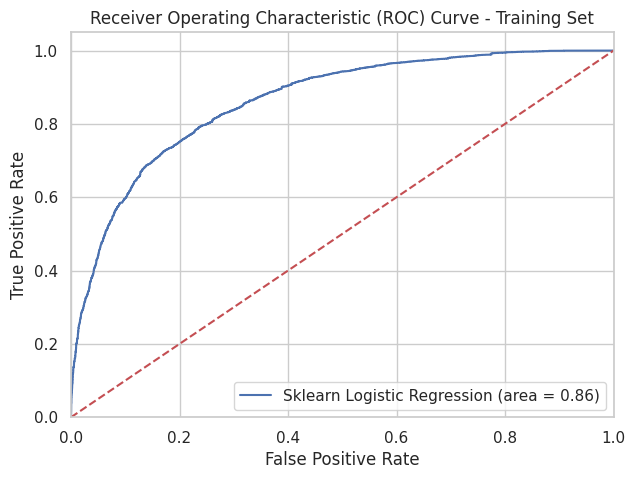

ROC-AUC on the training set (sklearn model): 0.8617


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for the training set using the sklearn model
y_train_pred_proba_sklearn = model_sklearn_scaled.predict_proba(X_train_scaled)[:, 1]

# Calculate ROC-AUC score on the training set
roc_auc_train_sklearn = roc_auc_score(y_train, y_train_pred_proba_sklearn)

# Calculate ROC curve
fpr_sklearn, tpr_sklearn, thresholds_sklearn = roc_curve(y_train, y_train_pred_proba_sklearn)

# Plot the ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr_sklearn, tpr_sklearn, label="Sklearn Logistic Regression (area = %0.2f)" % roc_auc_train_sklearn)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve - Training Set")
plt.legend(loc="lower right")
plt.show()

print(f"ROC-AUC on the training set (sklearn model): {roc_auc_train_sklearn:.4f}")

In [ ]:
# Make predictions on the test set for the initial statsmodels model
# Use the original X_test with the constant added for prediction with the lg model
X_test_original = sm.add_constant(df.drop(columns=['Booking_ID', 'total_nights','booking_status'], axis=1).loc[X_test.index].astype(float), prepend=True)
pred_test = lg.predict(X_test_original) > 0.5
pred_test = np.round(pred_test)

print("Accuracy on training set : ", accuracy_score(y_train, pred_train))
print("Accuracy on test set : ", accuracy_score(y_test, pred_test))

Accuracy on training set :  0.8028600964851826
Accuracy on test set :  0.8144727773949001


In [ ]:
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [ ]:
df = pd.read_csv("INNHotelsGroup.csv")

In [ ]:
df2=df.copy()

In [ ]:
print(df.columns)

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')


In [ ]:
for feature in df.columns: # Loop through all columns in the dataframe
    if df[feature].dtype == 'object': # Only apply for columns with categorical strings
        df[feature] = pd.Categorical(df[feature])# Replace strings with an integer
df.head(10)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
5,INN00006,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,2018,9,13,Online,0,0,0,115.00,1,Canceled
6,INN00007,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,2017,10,15,Online,0,0,0,107.55,1,Not_Canceled
7,INN00008,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,2018,12,26,Online,0,0,0,105.61,1,Not_Canceled
8,INN00009,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,2018,7,6,Offline,0,0,0,96.90,1,Not_Canceled
9,INN00010,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,2018,10,18,Online,0,0,0,133.44,3,Not_Canceled


In [ ]:
print(df.market_segment_type.value_counts())
print(df.room_type_reserved.value_counts())
print(df.type_of_meal_plan.value_counts())
print(df.arrival_year.value_counts())
print(df.booking_status.value_counts())

market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64
room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64
type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64
arrival_year
2018    29761
2017     6514
Name: count, dtype: int64
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


In [ ]:
replaceStruct = {
                "market_segment_type":     {"Online": 1, "Offline": 2 ,"Corporate": 3 ,"Complementary": 4, "Aviation": 5},
                "type_of_meal_plan": {"Meal Plan 1": 1, "Meal Plan 2":2 , "Meal Plan 3": 3, "Not Selected": 4},
                 "arrival_year": {"2018": 1, "2017":2},
                 "booking_status":     {"Not_Canceled ": 1, "Canceled": 2},
                "room_type_reserved":     {"Room_Type 1 ": 1, "Room_Type 2": 2 , "Room_Type 3": 3, "Room_Type 4": 4, "Room_Type 5": 5, "Room_Type 6": 6, "Room_Type 7": 7}
                    }
oneHotCols=["market_segment_type","type_of_meal_plan","arrival_year", "room_type_reserved"]


In [ ]:
df=df.replace(replaceStruct)
df = pd.get_dummies(df, columns=oneHotCols)
df.head(10)

/tmp/ipython-input-3246859065.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace(replaceStruct)
/tmp/ipython-input-3246859065.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df=df.replace(replaceStruct)
/tmp/ipython-input-3246859065.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace(rep

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_month,arrival_date,repeated_guest,...,type_of_meal_plan_4,arrival_year_2017,arrival_year_2018,room_type_reserved_Room_Type 1,room_type_reserved_2,room_type_reserved_3,room_type_reserved_4,room_type_reserved_5,room_type_reserved_6,room_type_reserved_7
0,INN00001,2,0,1,2,0,224,10,2,0,...,False,True,False,True,False,False,False,False,False,False
1,INN00002,2,0,2,3,0,5,11,6,0,...,True,False,True,True,False,False,False,False,False,False
2,INN00003,1,0,2,1,0,1,2,28,0,...,False,False,True,True,False,False,False,False,False,False
3,INN00004,2,0,0,2,0,211,5,20,0,...,False,False,True,True,False,False,False,False,False,False
4,INN00005,2,0,1,1,0,48,4,11,0,...,True,False,True,True,False,False,False,False,False,False
5,INN00006,2,0,0,2,0,346,9,13,0,...,False,False,True,True,False,False,False,False,False,False
6,INN00007,2,0,1,3,0,34,10,15,0,...,False,True,False,True,False,False,False,False,False,False
7,INN00008,2,0,1,3,0,83,12,26,0,...,False,False,True,False,False,False,True,False,False,False
8,INN00009,3,0,0,4,0,121,7,6,0,...,False,False,True,True,False,False,False,False,False,False
9,INN00010,2,0,0,5,0,44,10,18,0,...,False,False,True,False,False,False,True,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 33 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   Booking_ID                            36275 non-null  category
 1   no_of_adults                          36275 non-null  int64   
 2   no_of_children                        36275 non-null  int64   
 3   no_of_weekend_nights                  36275 non-null  int64   
 4   no_of_week_nights                     36275 non-null  int64   
 5   required_car_parking_space            36275 non-null  int64   
 6   lead_time                             36275 non-null  int64   
 7   arrival_month                         36275 non-null  int64   
 8   arrival_date                          36275 non-null  int64   
 9   repeated_guest                        36275 non-null  int64   
 10  no_of_previous_cancellations          36275 non-null  int64   
 11  no

In [ ]:
# Drop Booking_ID from features
X = df.drop(columns=['Booking_ID', 'booking_status'], axis=1)

# Define target variable
y = df['booking_status']

# Convert categorical features to one-hot encoded numerical features
X = pd.get_dummies(X, columns=['type_of_meal_plan', 'room_type_reserved', 'market_segment_type'], drop_first=True)

# Convert target variable to integer codes
y = y.cat.codes

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=1)

In [ ]:
#Build the decision tree model
dTree = DecisionTreeClassifier(criterion = 'gini', random_state=1)
dTree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
# Load dataset
df = pd.read_csv("INNHotelsGroup.csv")

In [ ]:
# Convert object columns to categorical types
for feature in df.columns:
    if df[feature].dtype == 'object':
        df[feature] = df[feature].astype('category')

# Display the data types to confirm
print(df.dtypes)

Booking_ID                              category
no_of_adults                               int64
no_of_children                             int64
no_of_weekend_nights                       int64
no_of_week_nights                          int64
type_of_meal_plan                       category
required_car_parking_space                 int64
room_type_reserved                      category
lead_time                                  int64
arrival_year                               int64
arrival_month                              int64
arrival_date                               int64
market_segment_type                     category
repeated_guest                             int64
no_of_previous_cancellations               int64
no_of_previous_bookings_not_canceled       int64
avg_price_per_room                       float64
no_of_special_requests                     int64
booking_status                          category
dtype: object


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=1)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

#Build the decision tree model
dTree = DecisionTreeClassifier(criterion = 'gini', random_state=1)
dTree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
#recall

def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth

    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
##  Function to calculate recall score
def get_recall_score(model):
    '''
    model : classifier to predict values of X

    '''
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
    print("Recall on test set : ",metrics.recall_score(y_test,pred_test))

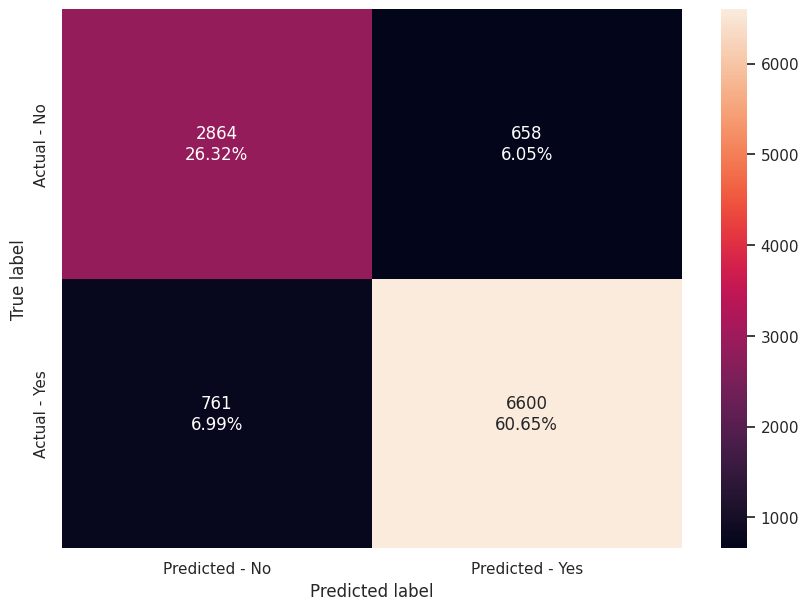

In [ ]:
make_confusion_matrix(dTree,y_test)

In [ ]:
# Recall on train and test
get_recall_score(dTree)

Recall on training set :  0.9957719184919842
Recall on test set :  0.8966173074310556


In [ ]:
feature_names = list(X.columns)
print(feature_names)

['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary', 'market_segment_type_Corporate', 'market_segment_type_Offline', 'market_segment_type_Online']


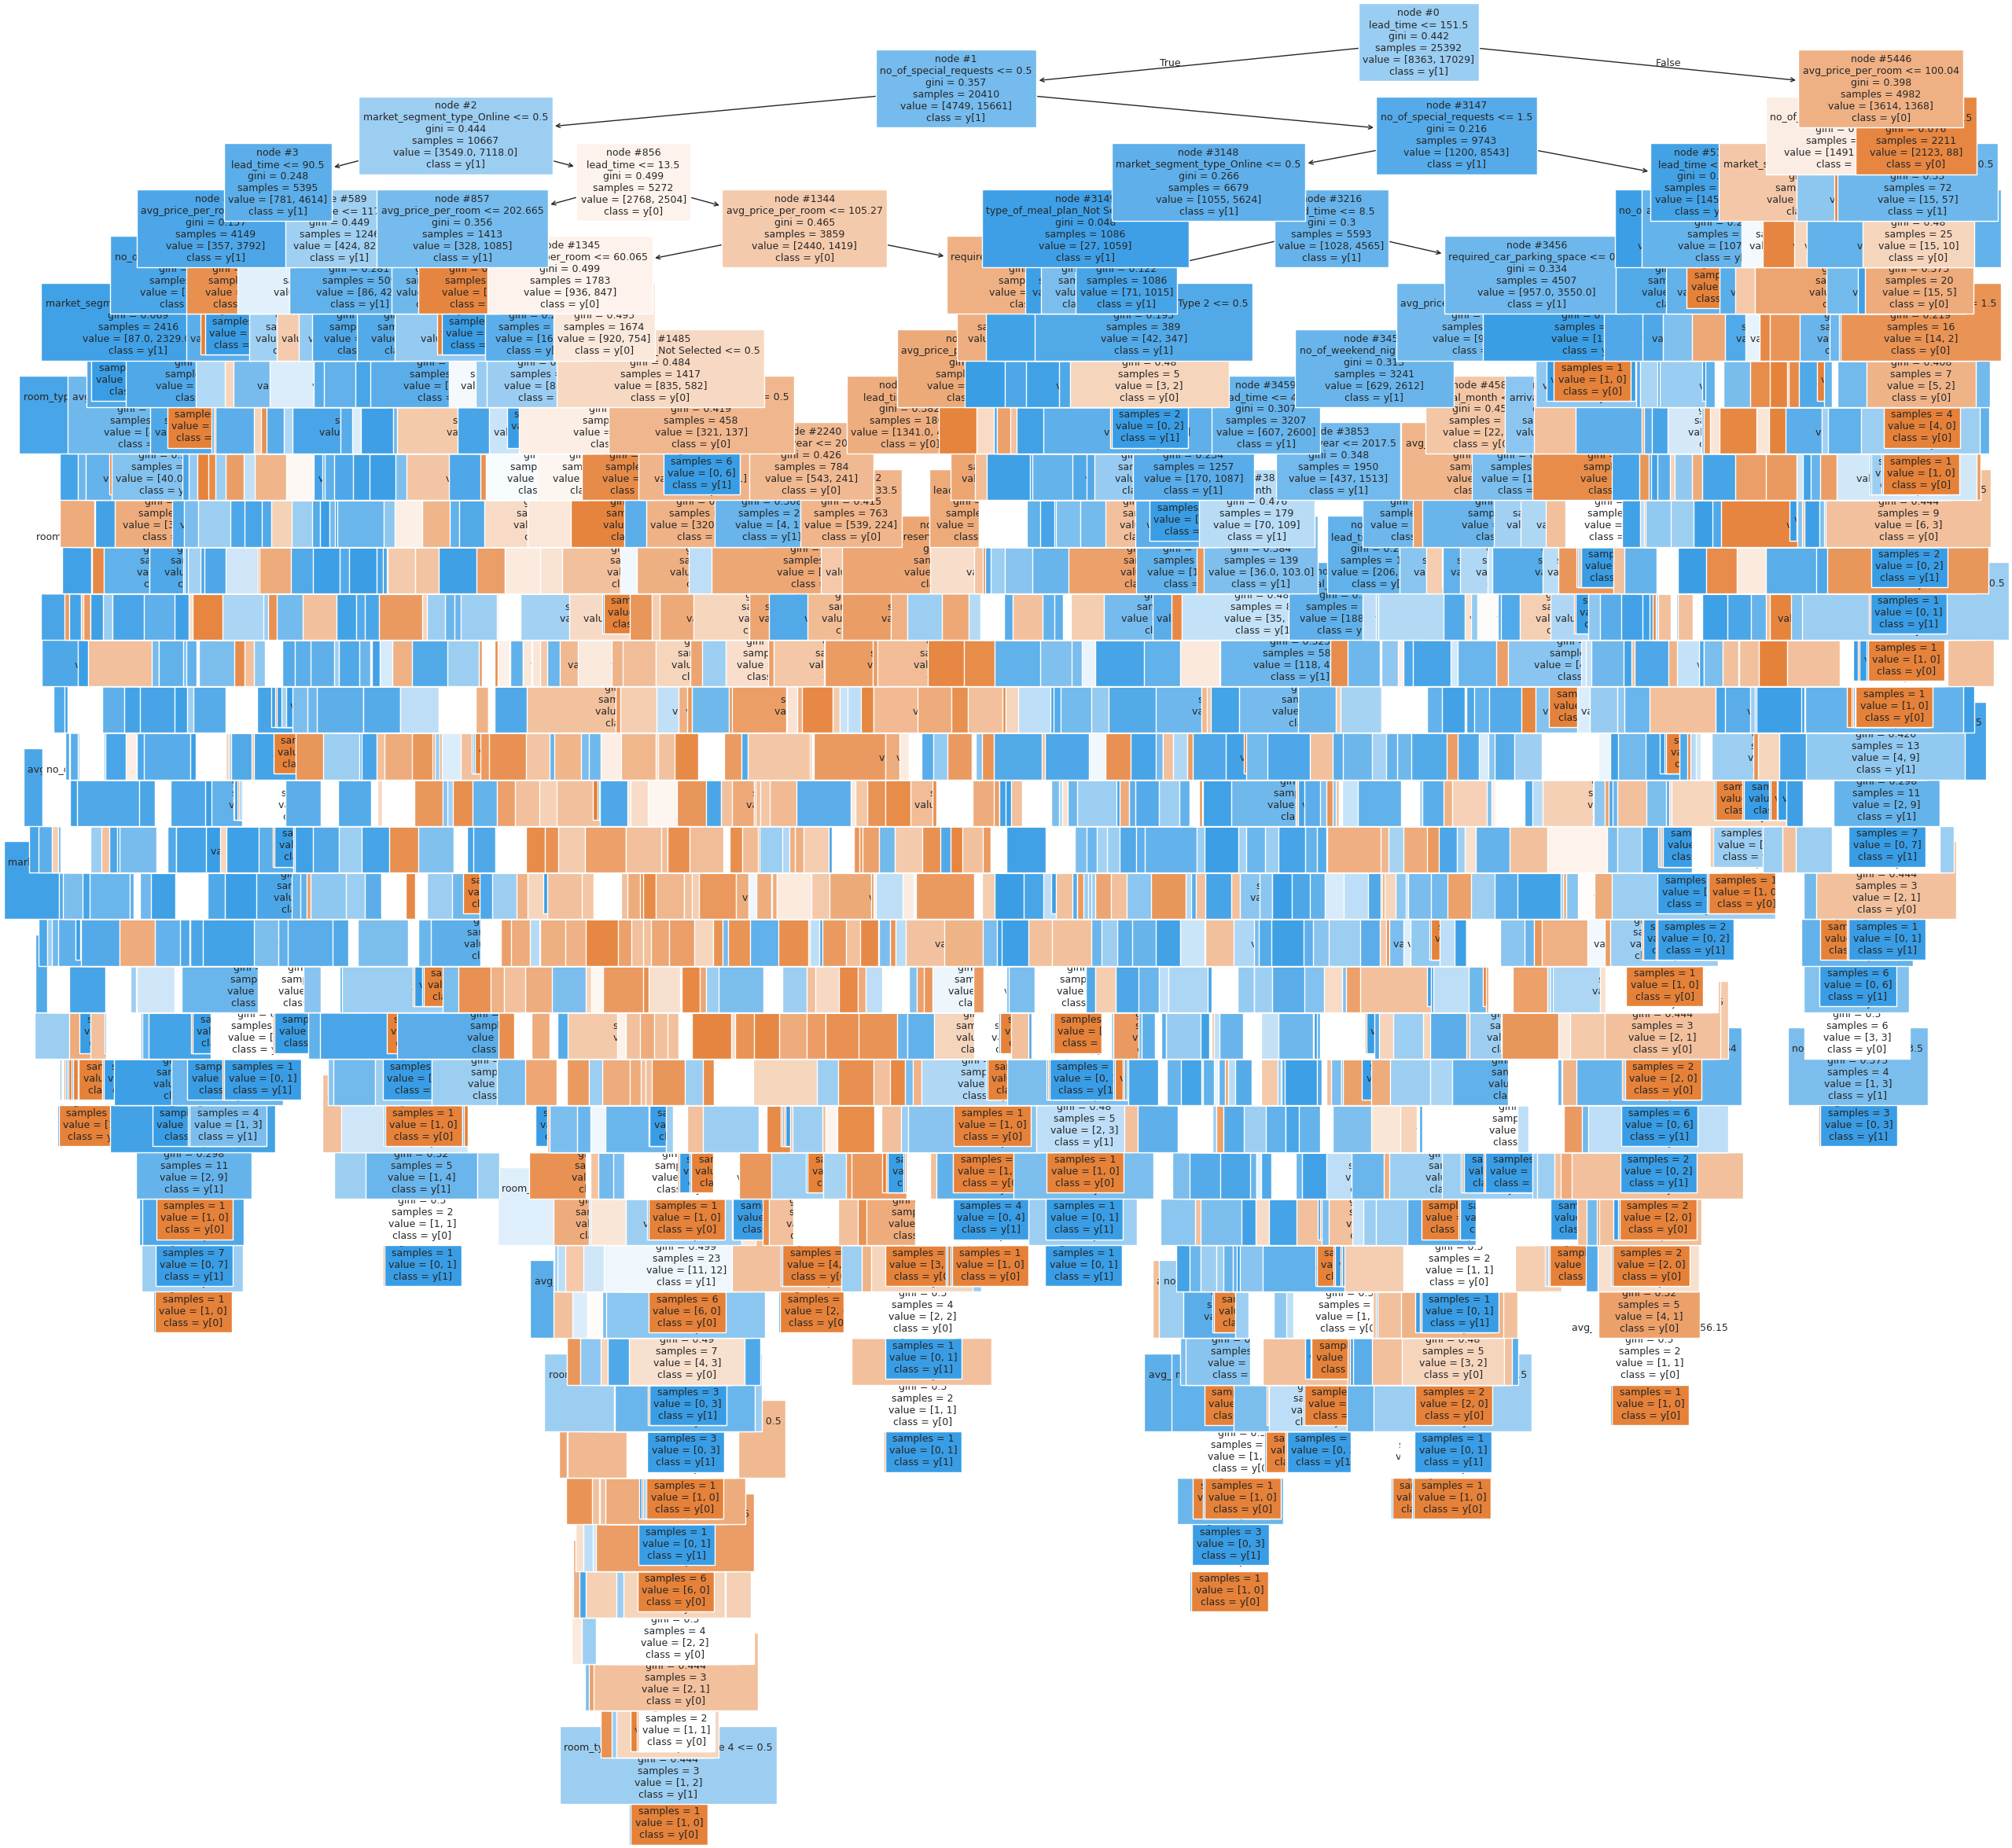

In [ ]:
plt.figure(figsize=(30,30))
tree.plot_tree(dTree,feature_names=feature_names,filled=True,fontsize=9,node_ids=True,class_names=True)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(dTree,feature_names=feature_names,show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- avg_price_per_room <= 201.50
|   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |   |--- lead_time <= 16.50
|   |   |   |   |   |   |   |   |--- room_type_reserved_Room_Type 4 <= 0.50
|   |   |   |   |   |   |   |   |   |--- repeated_guest <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- lead_time <= 11.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 13
|   |   |   |   |   |   |   |   |   |   |--- lead_time >  11.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |   |   |   |   |   |--- repeated_guest >  0.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 147.00] class: 1
|   |   |   |   |   |   |   |   |--- room_type_reserved_Room_Type

In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(dTree.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                           Imp
lead_time                             0.350353
avg_price_per_room                    0.177265
market_segment_type_Online            0.092345
arrival_date                          0.085259
no_of_special_requests                0.067948
arrival_month                         0.064570
no_of_week_nights                     0.045395
no_of_weekend_nights                  0.038528
no_of_adults                          0.027482
arrival_year                          0.011793
type_of_meal_plan_Not Selected        0.008234
room_type_reserved_Room_Type 4        0.006904
required_car_parking_space            0.006878
market_segment_type_Offline           0.003927
type_of_meal_plan_Meal Plan 2         0.003704
no_of_children                        0.003672
room_type_reserved_Room_Type 5        0.001681
room_type_reserved_Room_Type 2        0.001486
market_segment_type_Corporate         0.000646
repeated_guest                        0.000601
room_type_res

Feature Importances:
                                 feature  importance
5                              lead_time    0.350353
12                    avg_price_per_room    0.177265
26            market_segment_type_Online    0.092345
8                           arrival_date    0.085259
13                no_of_special_requests    0.067948
7                          arrival_month    0.064570
3                      no_of_week_nights    0.045395
2                   no_of_weekend_nights    0.038528
0                           no_of_adults    0.027482
6                           arrival_year    0.011793
16        type_of_meal_plan_Not Selected    0.008234
19        room_type_reserved_Room_Type 4    0.006904
4             required_car_parking_space    0.006878
25           market_segment_type_Offline    0.003927
14         type_of_meal_plan_Meal Plan 2    0.003704
1                         no_of_children    0.003672
20        room_type_reserved_Room_Type 5    0.001681
17        room_type_reser

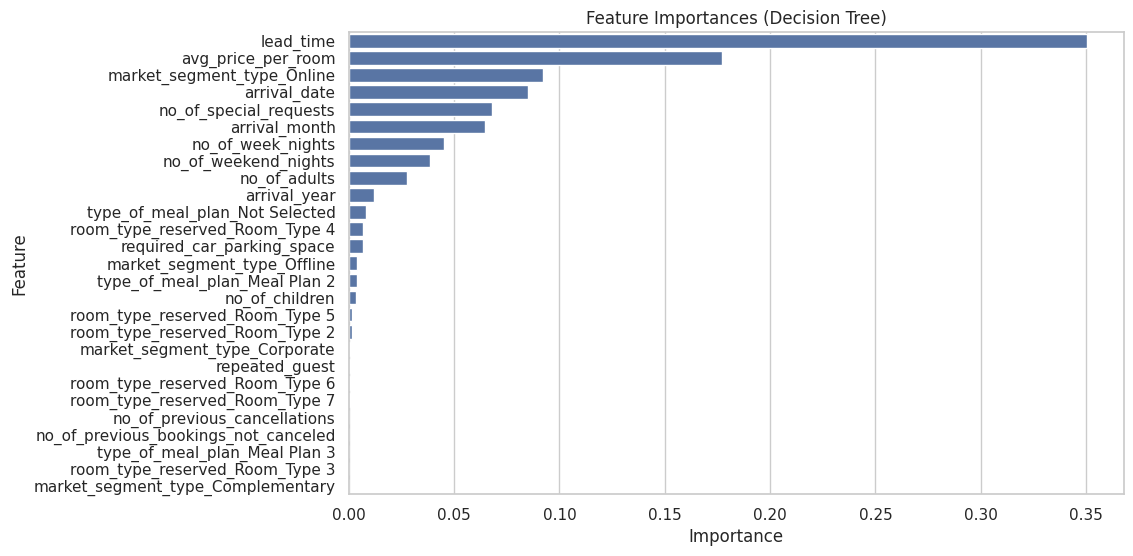

In [ ]:
# Get feature importances
feature_importances = dTree.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'feature': X_train.columns, 'importance': feature_importances})

# Sort features by importance
features_df = features_df.sort_values(by='importance', ascending=False)

# Display the feature importances
print("Feature Importances:")
print(features_df)

# Optionally, visualize the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=features_df)
plt.title('Feature Importances (Decision Tree)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, make_scorer

# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {'max_depth': [3, 5, 7, 10],
              'min_samples_split': [2, 5, 10, 20],
              'min_samples_leaf': [1, 5, 10, 20]}

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
best_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
best_estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, min_samples_split=5, random_state=1)

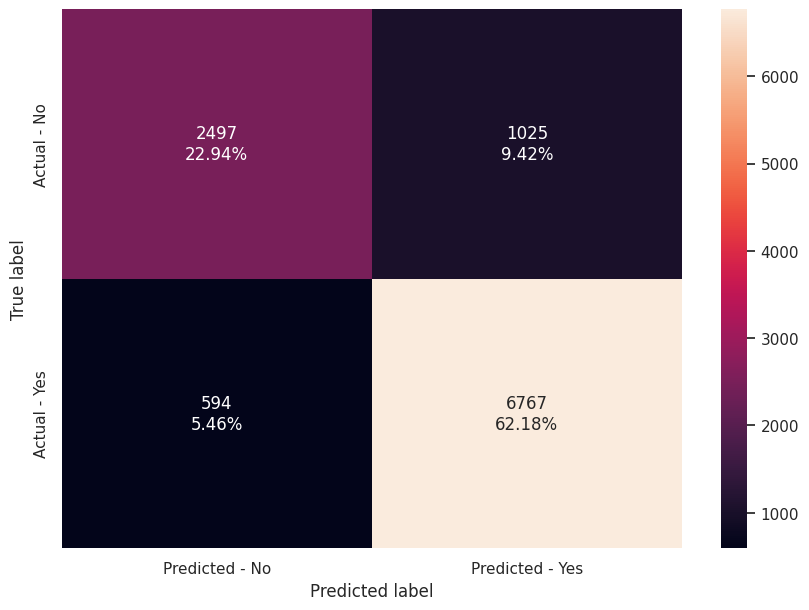

In [ ]:
make_confusion_matrix(best_estimator,y_test)

In [ ]:
# Accuracy on train and test
print("Accuracy on training set : ",best_estimator.score(X_train, y_train))
print("Accuracy on test set : ",best_estimator.score(X_test, y_test))
# Recall on train and test
get_recall_score(best_estimator)

Accuracy on training set :  0.8536940768746062
Accuracy on test set :  0.8512358724616375
Recall on training set :  0.9179634740736391
Recall on test set :  0.919304442331205


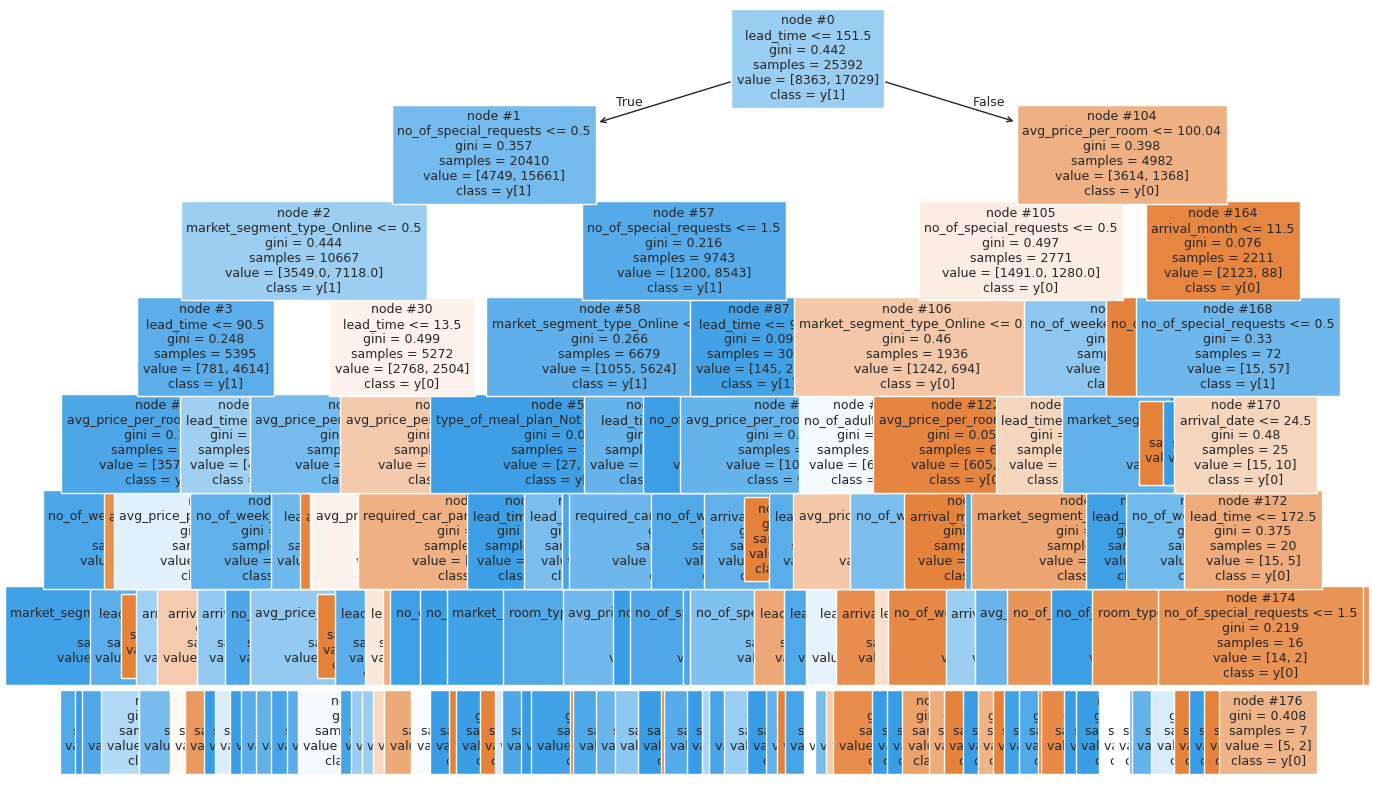

In [ ]:
plt.figure(figsize=(15,10))

tree.plot_tree(best_estimator,feature_names=feature_names,filled=True,fontsize=9,node_ids=True,class_names=True)
plt.show()

In [ ]:
print(tree.export_text(best_estimator,feature_names=feature_names,show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- avg_price_per_room <= 201.50
|   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |   |--- weights: [87.00, 720.00] class: 1
|   |   |   |   |   |   |--- market_segment_type_Offline >  0.50
|   |   |   |   |   |   |   |--- weights: [0.00, 1609.00] class: 1
|   |   |   |   |   |--- no_of_weekend_nights >  0.50
|   |   |   |   |   |   |--- lead_time <= 68.50
|   |   |   |   |   |   |   |--- weights: [147.00, 1288.00] class: 1
|   |   |   |   |   |   |--- lead_time >  68.50
|   |   |   |   |   |   |   |--- weights: [106.00, 173.00] class: 1
|   |   |   |   |--- avg_price_per_room >  201.50
|   |   |   |   |   |--- arrival_month <= 10.50
|   |   |   |   |   |   |--- weights: [17.00, 0.00] class: 0
|   |   |   |   |   |--- arrival_mont

In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
#(normalized) total reduction of the 'criterion' brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(best_estimator.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

#Here we will see that importance of features has increased

                                           Imp
lead_time                             0.466422
market_segment_type_Online            0.176866
avg_price_per_room                    0.137042
no_of_special_requests                0.125439
no_of_adults                          0.024762
arrival_month                         0.024297
no_of_weekend_nights                  0.016353
required_car_parking_space            0.009503
arrival_date                          0.009414
no_of_week_nights                     0.005929
market_segment_type_Offline           0.002118
room_type_reserved_Room_Type 2        0.000713
arrival_year                          0.000579
type_of_meal_plan_Not Selected        0.000494
market_segment_type_Corporate         0.000069
no_of_previous_cancellations          0.000000
repeated_guest                        0.000000
no_of_children                        0.000000
type_of_meal_plan_Meal Plan 2         0.000000
room_type_reserved_Room_Type 3        0.000000
type_of_meal_

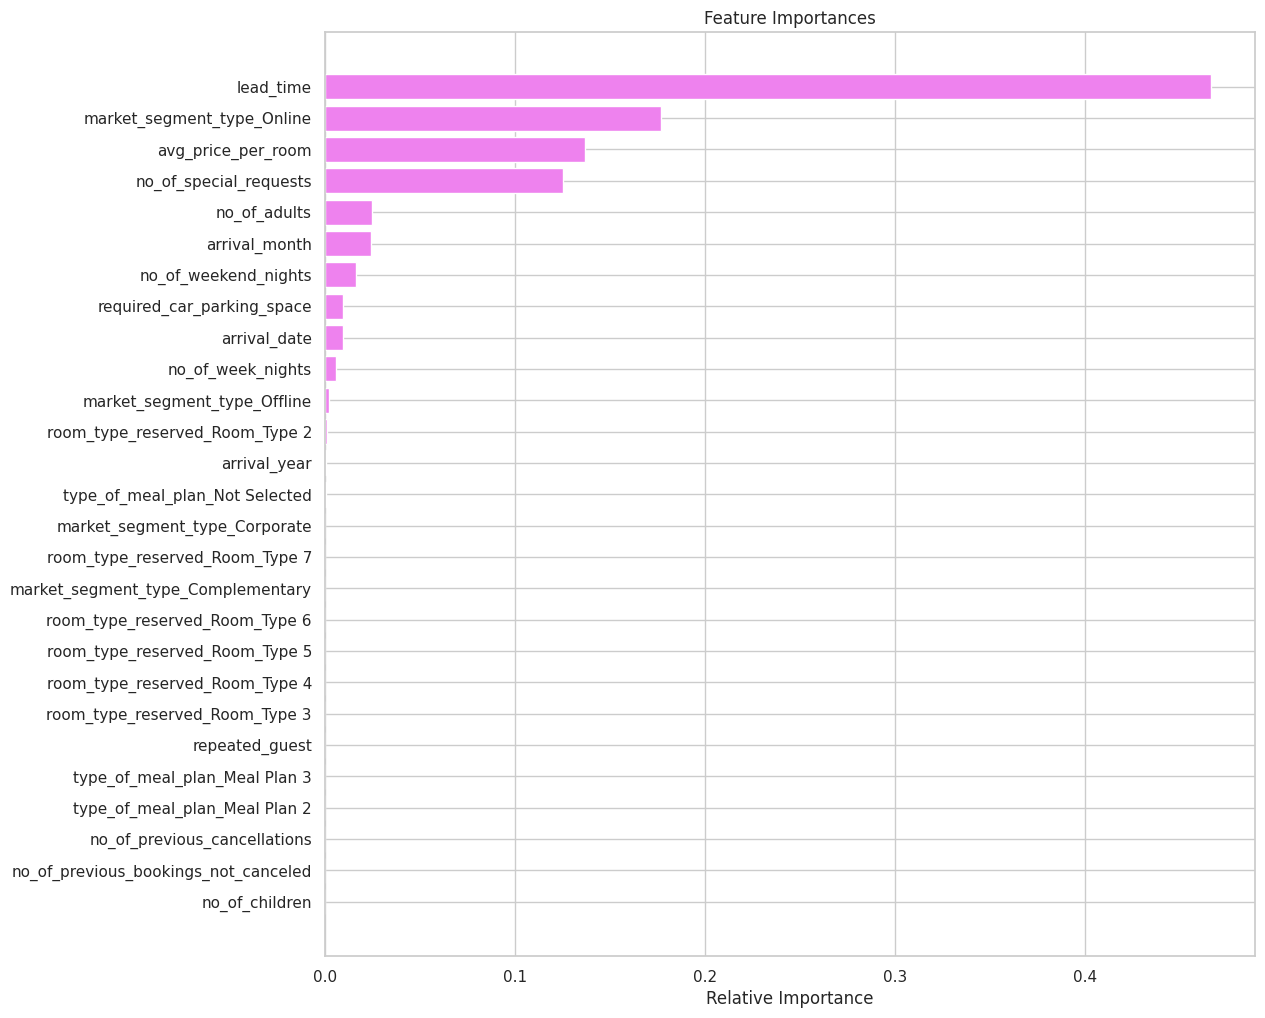

In [ ]:
importances = best_estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
#Total impurity of leaves vs effective alphas of pruned tree
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,0.007572
1,4.327745e-07,0.007573
2,4.688391e-07,0.007573
3,5.329960e-07,0.007574
4,6.133547e-07,0.007575
...,...,...
1340,6.665684e-03,0.286897
1341,1.304480e-02,0.299942
1342,1.725993e-02,0.317202
1343,2.399048e-02,0.365183


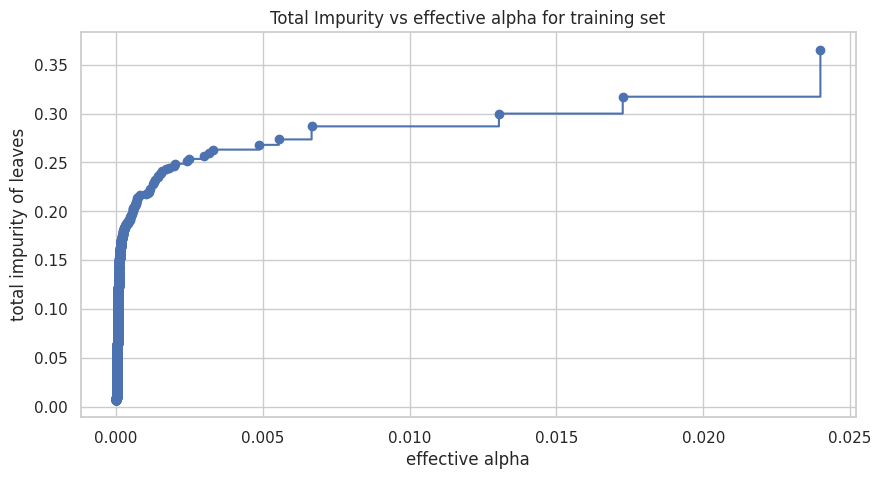

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [ ]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
      clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.07657789477371368


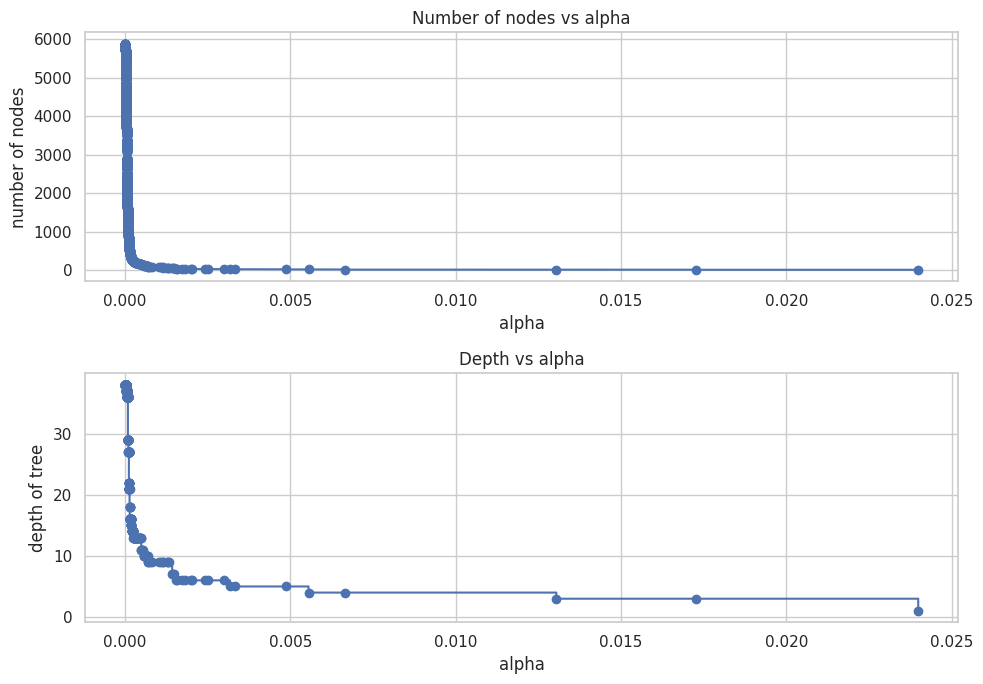

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1,figsize=(10,7))
ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

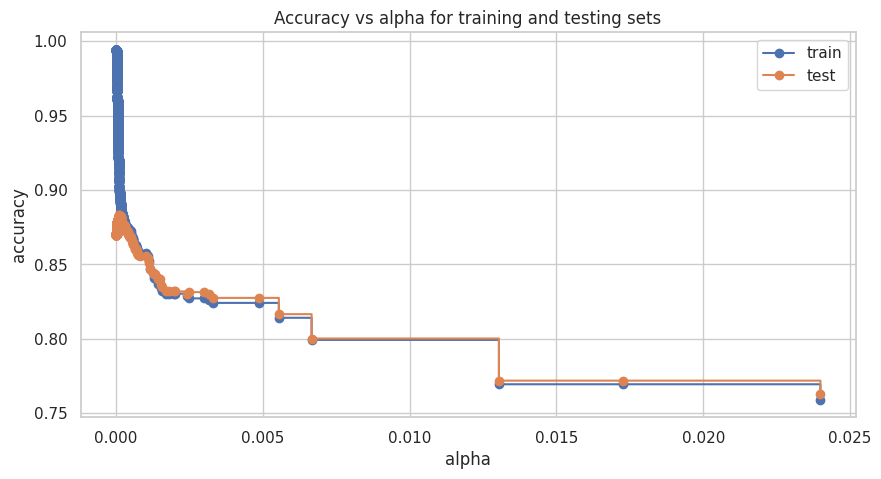

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
index_best_model = np.argmax(test_scores)
best_model = clfs[index_best_model]
print(best_model)
print('Training accuracy of best model: ',best_model.score(X_train, y_train))
print('Test accuracy of best model: ',best_model.score(X_test, y_test))

DecisionTreeClassifier(ccp_alpha=np.float64(0.00011736595788977046),
                       random_state=1)
Training accuracy of best model:  0.9029615626969124
Test accuracy of best model:  0.883304235964348


In [ ]:
recall_train=[]
for clf in clfs:
    pred_train3=clf.predict(X_train)
    values_train=metrics.recall_score(y_train,pred_train3)
    recall_train.append(values_train)

In [ ]:
recall_test=[]
for clf in clfs:
    pred_test3=clf.predict(X_test)
    values_test=metrics.recall_score(y_test,pred_test3)
    recall_test.append(values_test)

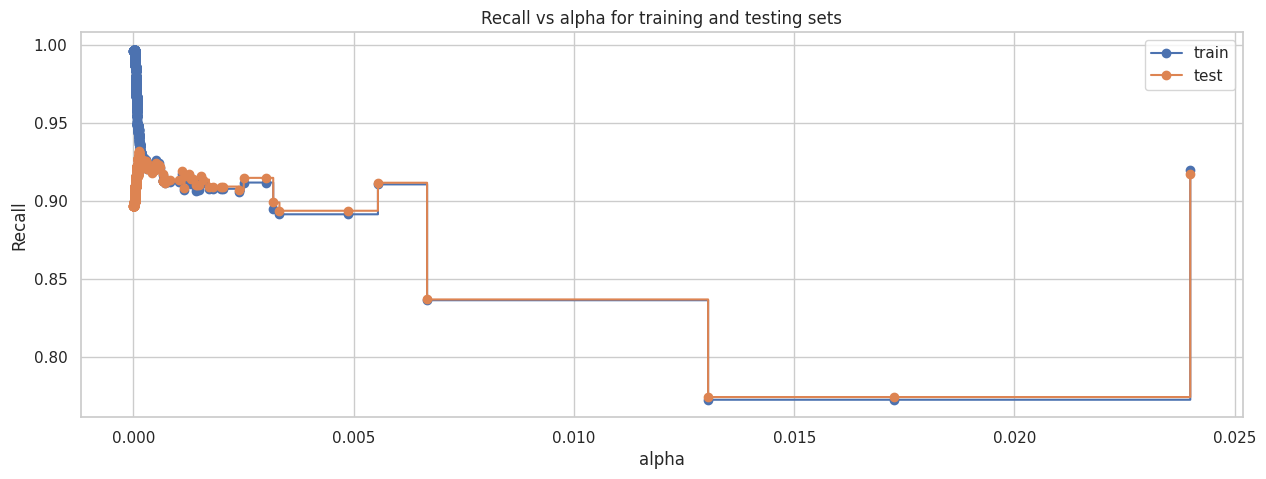

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.00012717831407730315),
                       random_state=1)


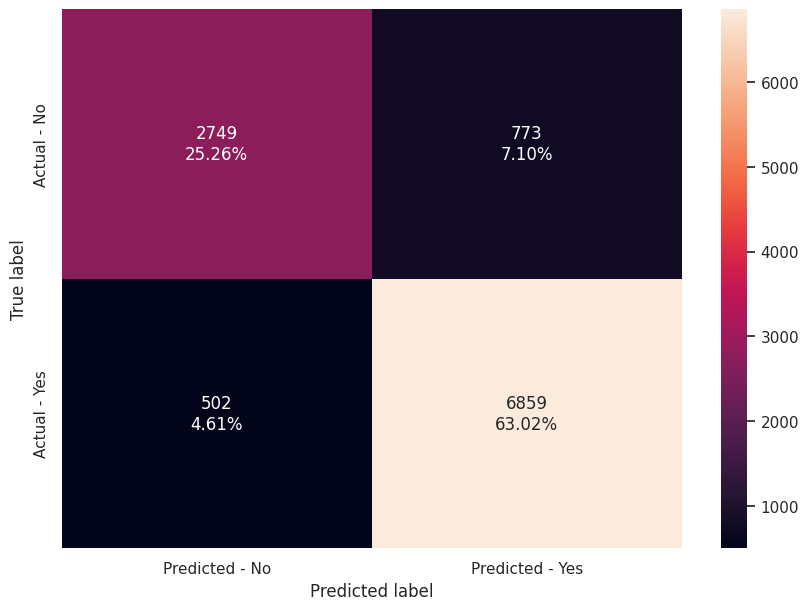

In [ ]:
make_confusion_matrix(best_model,y_test)

In [ ]:
# Recall on train and test
get_recall_score(best_model)

Recall on training set :  0.9417464325562276
Recall on test set :  0.9318027441923652


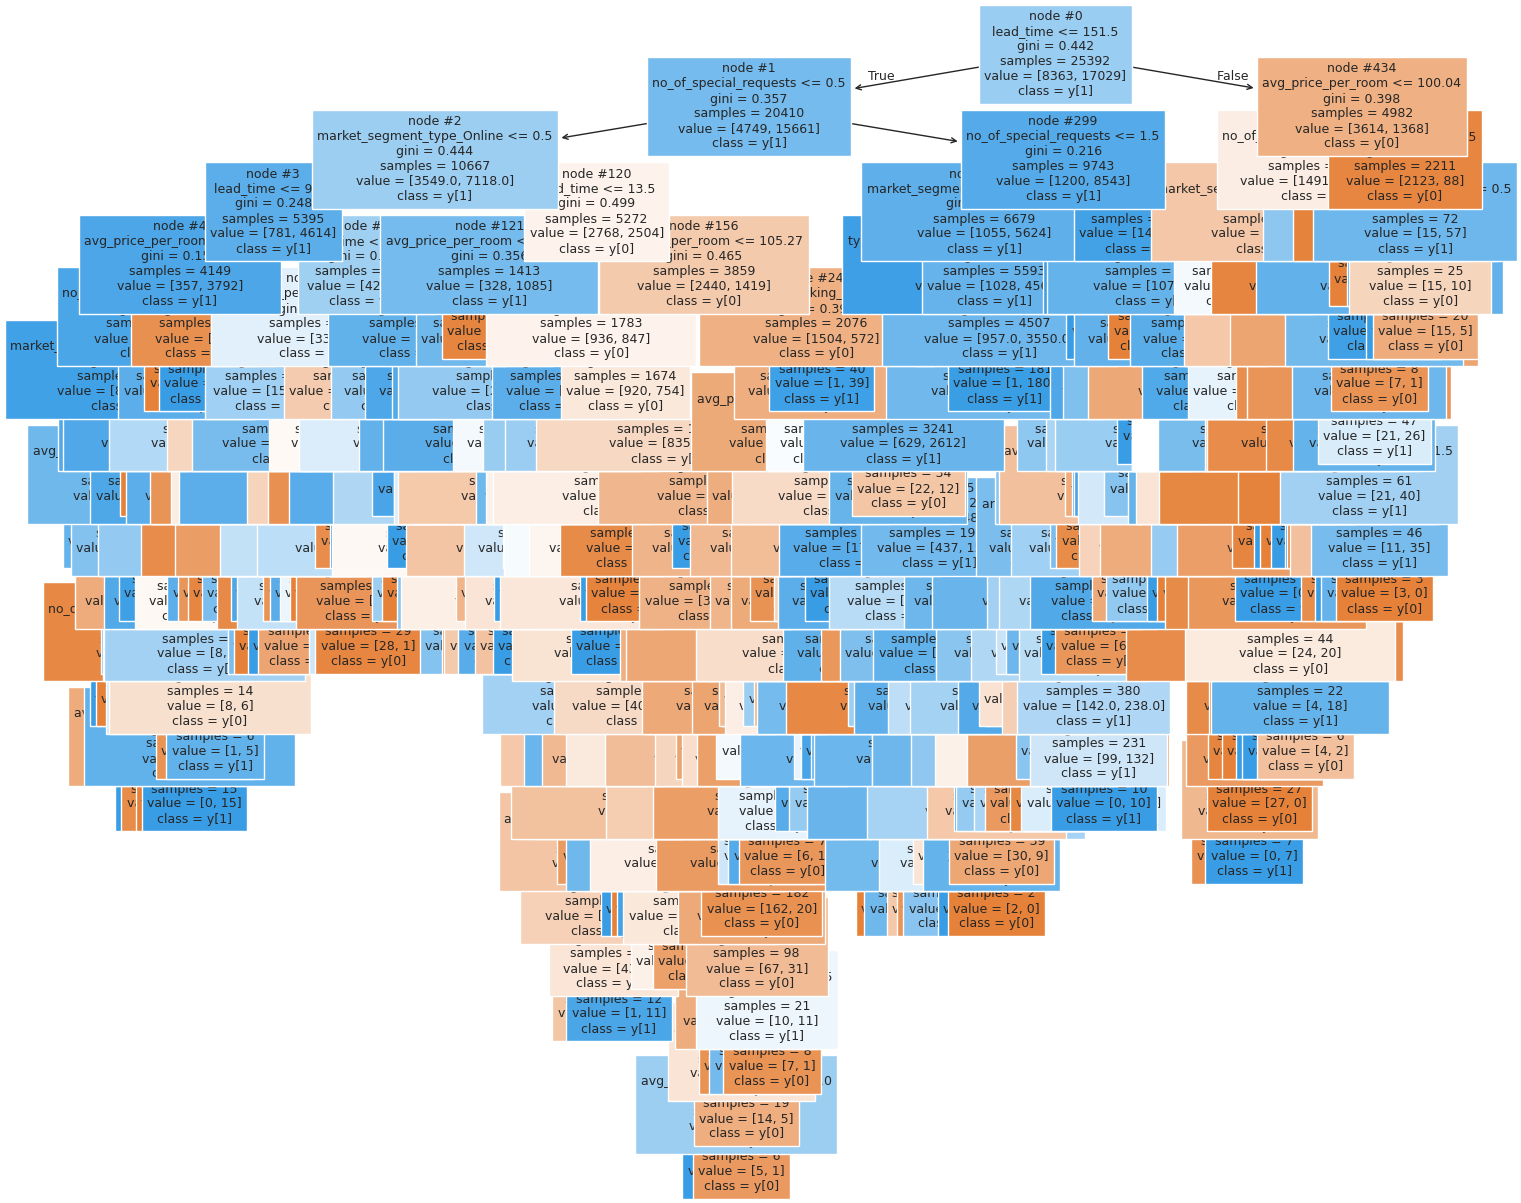

In [ ]:
plt.figure(figsize=(17,15))

tree.plot_tree(best_model,feature_names=feature_names,filled=True,fontsize=9,node_ids=True,class_names=True)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(best_model,feature_names=feature_names,show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- avg_price_per_room <= 201.50
|   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |   |--- lead_time <= 16.50
|   |   |   |   |   |   |   |   |--- weights: [43.00, 558.00] class: 1
|   |   |   |   |   |   |   |--- lead_time >  16.50
|   |   |   |   |   |   |   |   |--- avg_price_per_room <= 135.00
|   |   |   |   |   |   |   |   |   |--- weights: [36.00, 162.00] class: 1
|   |   |   |   |   |   |   |   |--- avg_price_per_room >  135.00
|   |   |   |   |   |   |   |   |   |--- weights: [8.00, 0.00] class: 0
|   |   |   |   |   |   |--- market_segment_type_Offline >  0.50
|   |   |   |   |   |   |   |--- weights: [0.00, 1609.00] class: 1
|   |   |   |   |   |--- no_of_weekend_nights >  0.50
|   |   |   |   |   |   |--- lead_time <= 

In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
#(normalized) total reduction of the 'criterion' brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(best_model.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                           Imp
lead_time                             0.402838
avg_price_per_room                    0.155707
market_segment_type_Online            0.138645
no_of_special_requests                0.100398
arrival_month                         0.056324
arrival_date                          0.034973
no_of_weekend_nights                  0.031197
no_of_adults                          0.023968
no_of_week_nights                     0.017755
arrival_year                          0.014170
required_car_parking_space            0.010020
market_segment_type_Offline           0.005098
type_of_meal_plan_Not Selected        0.002692
type_of_meal_plan_Meal Plan 2         0.002174
room_type_reserved_Room_Type 4        0.001874
room_type_reserved_Room_Type 5        0.001078
room_type_reserved_Room_Type 2        0.000613
no_of_children                        0.000475
repeated_guest                        0.000000
no_of_previous_cancellations          0.000000
room_type_res

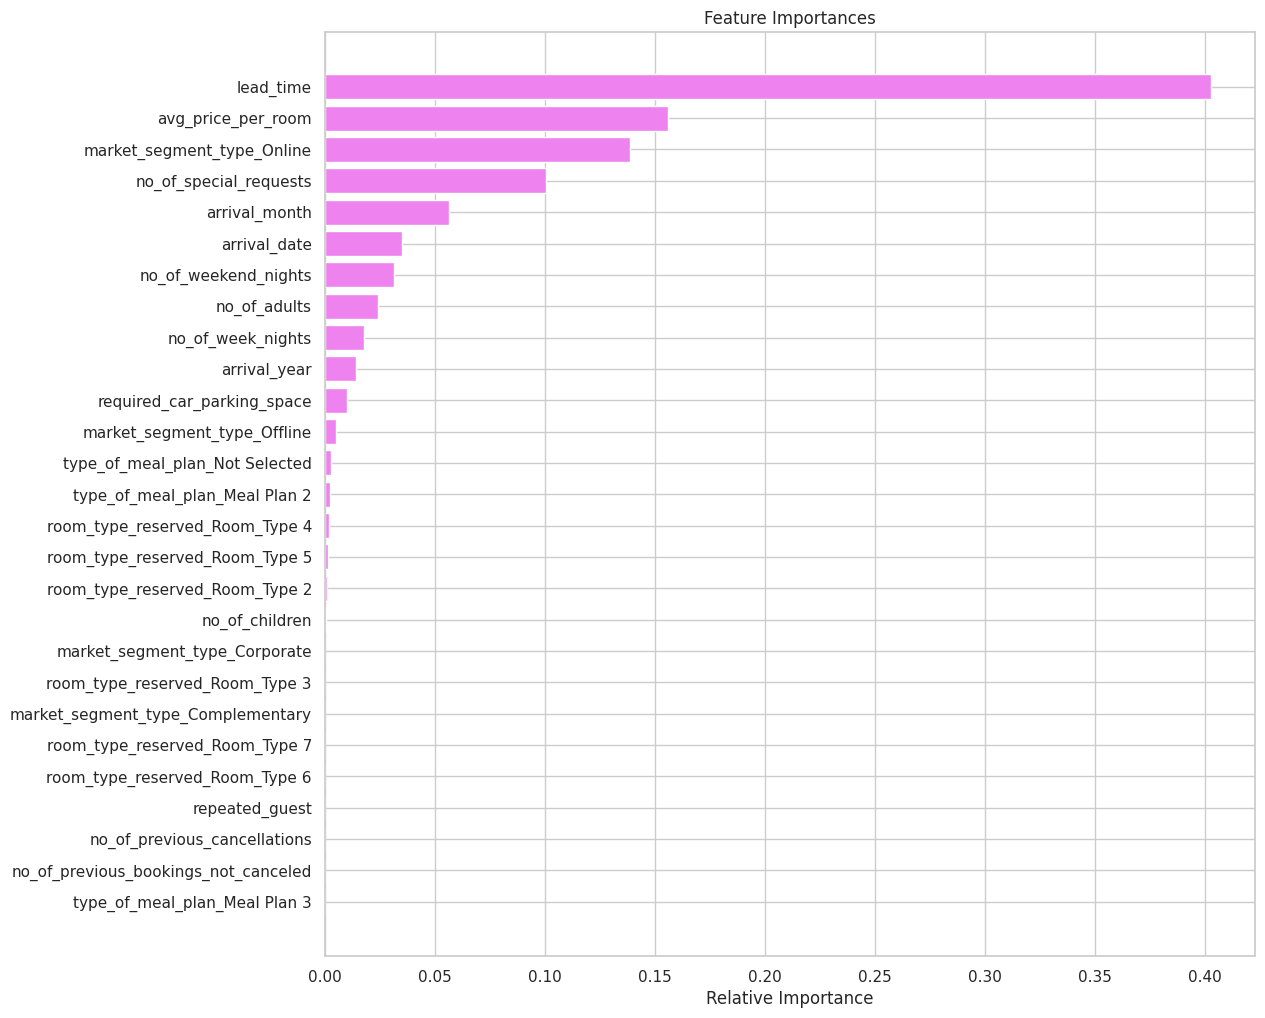

In [ ]:
importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
comparison_frame = pd.DataFrame({'Model':['Initial decision tree model','Decision tree with restricted maximum depth','Decision treee with hyperparameter tuning',
                                         'Decision tree with post-pruning'], 'Train_Recall':[1,0.53,0.51,0.63], 'Test_Recall':[0.46,0.46,0.46,0.56]})
comparison_frame

,Model,Train_Recall,Test_Recall
0,Initial decision tree model,1.00,0.46
1,Decision tree with restricted maximum depth,0.53,0.46
2,Decision treee with hyperparameter tuning,0.51,0.46
3,Decision tree with post-pruning,0.63,0.56
